# Tuần 06 — Khái quát dữ liệu (2/7): Phân phối xác suất và biến ngẫu nhiên rời rạc

**UET.MAT1052 — Xác suất thống kê**
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

### Câu hỏi của buổi

Tuần 05 tính xác suất của **một** biến cố, chẳng hạn tổng hai xúc xắc bằng 7. Tuần này ta hỏi: làm sao mô tả **toàn bộ** các giá trị mà một đại lượng ngẫu nhiên có thể nhận, cùng xác suất của từng giá trị?

### Sau buổi này, bạn làm được

- phân biệt xác suất lý thuyết với tần suất trong dữ liệu mô phỏng;
- dùng quy tắc nhân, chỉnh hợp và tổ hợp để đếm số kết quả;
- viết một biến ngẫu nhiên như một hàm trên không gian mẫu và lập hàm khối xác suất (PMF);
- lập và đọc hàm phân phối tích lũy (CDF), không nhầm dấu $<$ với $\le$;
- chọn mô hình đều rời rạc, Bernoulli, nhị thức, siêu bội hoặc Poisson, và nêu điều kiện của mô hình;
- tính tay trên ví dụ nhỏ, kiểm tra bằng SciPy và mô phỏng, rồi diễn giải bằng lời.

### Cần nhớ từ các buổi trước

- **Công thức đếm** (Tuần 05). Khi các kết quả đồng khả năng, $P(A)=\lvert A\rvert/\lvert\Omega\rvert$. Ví dụ: tổng hai xúc xắc bằng 7 có 6 trong 36 cặp.
- **Quy tắc nhân và độc lập** (Tuần 05). Hai lần tung độc lập: $P(\text{ngửa, ngửa})=\frac12\cdot\frac12=\frac14$.
- **Quy tắc cộng cho biến cố xung khắc** (Tuần 05). $P(\text{tổng}=2\text{ hoặc }12)=\frac1{36}+\frac1{36}$.
- **Có và không hoàn lại** (Tuần 05). Rút không hoàn lại làm đổi thành phần hộp, nên các lần rút phụ thuộc nhau.

### Cách học notebook này

1. **Đọc** đề ví dụ.
2. **Đoán** hoặc tự giải trước khi chạy ô code hay mở đáp án.
3. **Chạy** ô bằng `Shift + Enter`.
4. **So sánh** kết quả với dự đoán.

Khối **Vì sao?** chứa chứng minh; khối **Nhắc lại** ôn kiến thức nền. Các bài trong buổi được đặt tên **Ví dụ 1–21**. Chạy từ đầu bằng **Restart Kernel → Run All**. Mọi dữ liệu ngẫu nhiên trong bài đều là dữ liệu mô phỏng theo mô hình đã nêu, chưa phải dữ liệu thật về một tổng thể.

### Bản đồ bài học

1. Bảng phân phối và tần suất thực nghiệm
2. Quy tắc đếm
3. Biến ngẫu nhiên và hàm khối xác suất
4. Hàm phân phối tích lũy
5. Các phân phối rời rạc thông dụng: đều, Bernoulli, nhị thức, siêu bội
6. Phân phối Poisson
7. Dịch câu hỏi thành xác suất và chọn mô hình
8. Hai bài toán tổng hợp
9. Tóm tắt và lỗi hay gặp
10. Tự kiểm tra trước Tuần 07
11. Đọc thêm

Mọi hình dùng Plotnine. Ảnh hình đã được lưu sẵn; để đổi tham số, chạy kernel rồi kéo thanh trượt ipywidgets, hoặc sửa giá trị trong ô code rồi chạy lại. Các hoạt động này không cần đọc dữ liệu từ mạng.

**Thực hành Plot:** [hướng dẫn Plotnine](./HUONG_DAN_PLOT.md). Các đoạn “Đọc code vẽ” trong bài giải thích những API được dùng ở từng hình. Ô mô phỏng có thể sinh mẫu mới khi chạy lại; để so sánh hai cách vẽ trên cùng mẫu, khởi động lại kernel và chạy toàn bộ notebook với cùng seed sau mỗi lần sửa.

## Lộ trình học buổi 6

| Cách học | Nội dung cần làm |
|---|---|
| Học trên lớp | Mục 1–7: phép đếm, biến ngẫu nhiên, PMF/CDF và điều kiện chọn phân phối. |
| Tự luyện | Mục 8 và 10: dịch bài toán thành biến ngẫu nhiên, chọn mô hình rồi kiểm tra xác suất. |
| Đọc sâu | Các khối Vì sao? về chuẩn hóa, Vandermonde và giới hạn Poisson; học sau khi phân biệt được cơ chế lấy mẫu. |

Trước mỗi ô code chính, dự đoán kết quả bằng một câu; sau khi chạy, nêu kết luận cùng giả định và đơn vị. Khối đáp án dùng để đối chiếu sau khi tự làm. Các chứng minh trong khối **Vì sao?** được giữ đầy đủ để đọc lại, không cần mở đồng loạt khi đang học ví dụ chính.

Đi đến các phần: [1. Bảng phân phối và tần suất thực nghiệm](#hoc-f263e613) · [2. Quy tắc đếm](#hoc-c70ccfbf) · [3. Biến ngẫu nhiên gán con số cho kết quả](#hoc-r6-003) · [4. Hàm phân phối tích lũy trả lời câu hỏi về ngưỡng](#hoc-074d33fe) · [5. Các phân phối rời rạc thông dụng](#hoc-1b157ebd) · [6. Phân phối Poisson: đếm sự kiện trong một khoảng](#hoc-7e8bbdfe) · [7. Dịch câu hỏi thành xác suất và chọn mô hình](#hoc-42fbaac1) · [8. Hai bài toán tổng hợp](#hoc-ffef637c) · [9. Tóm tắt và lỗi hay gặp](#hoc-r6-005) · [10. Tự kiểm tra trước Tuần 07](#hoc-7d4cb0d0) · [11. Đọc thêm trong STAT 20 bản dịch](#hoc-r6-006)


## Ký hiệu dùng trong buổi này

| Ký hiệu | Đọc là | Nghĩa | Ví dụ |
|---|---|---|---|
| $X$, $Y$ | biến ngẫu nhiên X | quy tắc gán một con số cho mỗi kết quả của phép thử | $X$ = số mặt ngửa trong 3 lần tung |
| $x$, $k$ | x, k | một giá trị cụ thể | $x=2$ |
| $\{X=x\}$ | biến cố X bằng x | tập các kết quả mà ở đó $X$ nhận giá trị $x$ | $\{X=2\}=\{\mathrm{HHT},\mathrm{HTH},\mathrm{THH}\}$ |
| $p_X(x)$ | hàm khối xác suất của X tại x | $P(X=x)$ | $p_X(2)=3/8$ |
| $F_X(t)$ | hàm phân phối tích lũy của X tại t | $P(X\le t)$ | $F_X(1)=1/8+3/8=1/2$ |
| $\widehat p_m(x)$ | p mũ của x | tần suất của giá trị $x$ trong $m$ lần lặp | $\widehat p_{50}(2)=24/50$ |
| $n!$ | n giai thừa | $1\cdot2\cdots n$; quy ước $0!=1$ | $4!=24$ |
| $A_n^k$ | chỉnh hợp chập k của n | số cách chọn $k$ phần tử **có** thứ tự từ $n$ phần tử | $A_5^3=60$ |
| $\binom nk$ | n chọn k; tổ hợp chập k của n | số cách chọn $k$ phần tử **không** tính thứ tự | $\binom53=10$ |
| $X\sim\operatorname{Binomial}(n,p)$ | X có phân phối nhị thức với tham số n và p | | $\operatorname{Binomial}(20;\ 0{,}25)$ |
| $e$ | số e | $e\approx2{,}71828$ | $e^{-1}\approx0{,}3679$ |
| $\lambda$ | lam-đa | tham số Poisson: số sự kiện trung bình trong khoảng đang đếm | 4 yêu cầu mỗi giây |

**Cách viết khác.** Sách phổ thông Việt Nam viết $\binom nk$ là $C_n^k$. Bản dịch STAT 20 viết hàm khối xác suất là $f(x)$, nhị thức là $Bin(n,p)$, siêu bội là $HG(N,G,n)$ (chữ $G$ ứng với $K$ ở đây), Poisson là $Pois(\lambda)$. Một số giáo trình định nghĩa $F(x)=P(X<x)$ thay vì $P(X\le x)$; với biến rời rạc, hai định nghĩa cho kết quả khác nhau tại các giá trị mà $X$ có thể nhận.

**Chữ hoa, chữ thường.** $X$ (chữ hoa) là biến ngẫu nhiên, chưa biết sẽ nhận giá trị nào. $x$ (chữ thường) là một con số cụ thể. $P(X=x)$ đọc là "xác suất để $X$ nhận giá trị $x$".

## Thiết lập tính toán

Ô code dưới nạp các thư viện dùng trong buổi.

- `itertools`: liệt kê mọi cách chọn (`product`, `permutations`, `combinations`).
- `comb`, `factorial`: tính $\binom nk$ và $n!$ bằng số nguyên chính xác.
- `np`, `pd`: tính toán và lập bảng.
- `stats`: các phân phối của SciPy. Mỗi phân phối có ba hàm hay dùng: `pmf(k)` cho $P(X=k)$, `cdf(k)` cho $P(X\le k)$ và `sf(k)` cho $P(X>k)$.
- Thư viện vẽ hình của phiên bản này (xem dòng **Thực hành Plot** ở đầu bài).
- `rng = np.random.default_rng(42)`: bộ sinh số ngẫu nhiên với seed 42. Chạy lại toàn bộ notebook sẽ cho cùng dữ liệu mô phỏng; các xác suất lý thuyết không phụ thuộc seed.

In [1]:
import itertools
from math import comb, factorial
import numpy as np
import pandas as pd
from scipy import stats
import plotnine as p9
from IPython.display import display

p9.options.figure_format = 'png'
p9.theme_set(p9.theme_bw(base_size=11) + p9.theme(
    figure_size=(7, 4), dpi=100, legend_position='bottom',
    plot_title=p9.element_text(size=12)))
rng = np.random.default_rng(42)
pd.set_option('display.max_columns', 20)
print('Sẵn sàng: mọi dữ liệu ngẫu nhiên trong bài đều là dữ liệu mô phỏng.')

Sẵn sàng: mọi dữ liệu ngẫu nhiên trong bài đều là dữ liệu mô phỏng.


<a id="hoc-f263e613"></a>
## 1. Bảng phân phối và tần suất thực nghiệm

### Ví dụ 1 — Một hộp có năm lá thăm

Hộp chứa các lá ghi $1,2,2,3,4$. Rút một lá ngẫu nhiên; mỗi **lá** có xác suất $\frac15$. Gọi $X$ là số trên lá được rút.

**Bạn đoán trước:** $X$ nhận những giá trị nào, và mỗi giá trị có xác suất bao nhiêu?

Có hai lá ghi 2, nên $P(X=2)=\frac15+\frac15=\frac25$. Mỗi giá trị còn lại nằm trên một lá, nên có xác suất $\frac15$.

| Giá trị $x$ | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| $P(X=x)$ | $1/5$ | $2/5$ | $1/5$ | $1/5$ |

Bảng này là **phân phối xác suất** của $X$: nó cho biết tổng xác suất 1 được chia cho các giá trị của $X$ như thế nào. Năm **lá** đồng khả năng không có nghĩa là bốn **con số** đồng khả năng. Đó là khác biệt giữa kết quả vật lý của phép rút và giá trị mà ta ghi lại.

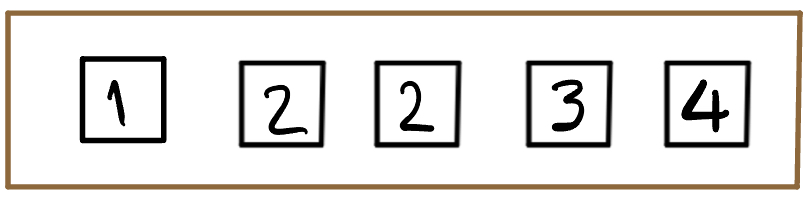

*Hình 1.1.* Hộp có năm lá thăm, hai lá cùng ghi số 2.  
*Nguồn ảnh: bản dịch STAT 20, §3.4.1.1 (tệp gốc: `figures/stat20_hop_nam_la.jpg`).*

### Hình 6.1. Vẽ một phân phối

Mỗi cột có bề rộng 1, đặt tại một giá trị nguyên. Chiều cao cột bằng xác suất; vì bề rộng là 1 nên diện tích cột cũng bằng xác suất, và tổng diện tích là 1. Hình này vẽ từ lý thuyết, không cần rút mẫu.

Đọc hình theo Ngữ pháp đồ họa (Tuần 03): dữ liệu là bảng $(x,\ p_X(x))$; $x$ ánh xạ vào vị trí ngang, xác suất vào chiều cao; dạng hình học là cột. Khi các giá trị không cách đều nhau một đơn vị, cần phân biệt biểu đồ cột của PMF với histogram, nơi diện tích biểu diễn xác suất.

Trong code, `p_hop` là bảng xác suất; `assert np.isclose(p_hop.sum(), 1)` kiểm tra tổng bằng 1.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

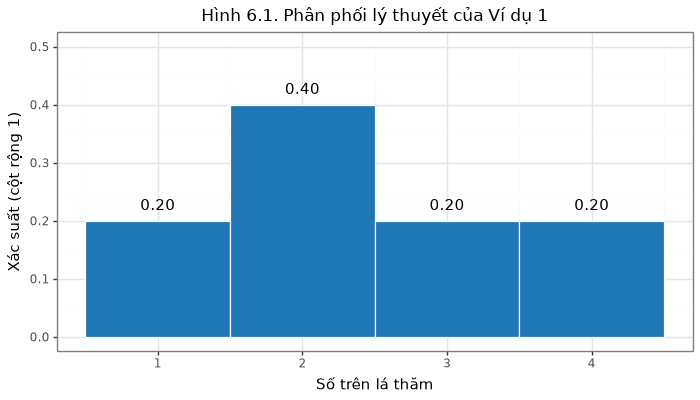

In [2]:
hop = np.array([1, 2, 2, 3, 4])
x_hop = np.arange(1, 5)
p_hop = np.array([1, 2, 1, 1]) / 5
assert np.isclose(p_hop.sum(), 1)

du_lieu_hop = pd.DataFrame({'x': x_hop, 'p': p_hop,
                           'nhan': [f'{p:.2f}' for p in p_hop]})
bieu_do = (p9.ggplot(du_lieu_hop, p9.aes('x', 'p'))
    + p9.geom_col(width=1, fill='#1f77b4', color='white')
    + p9.geom_text(p9.aes(label='nhan'), nudge_y=0.012, va='bottom')
    + p9.scale_x_continuous(breaks=x_hop)
    + p9.coord_cartesian(ylim=(0, 0.5))
    + p9.labs(x='Số trên lá thăm', y='Xác suất (cột rộng 1)',
              title='Hình 6.1. Phân phối lý thuyết của Ví dụ 1'))
bieu_do.show()

### Từ xác suất lý thuyết đến tần suất tương đối

Rút **có hoàn lại** $m$ lần rồi đếm. Nếu số $x$ xuất hiện $n_x$ lần, **tần suất tương đối** của $x$ là

$$\widehat p_m(x)=\frac{n_x}{m}.$$

Đọc là: tỉ lệ số lần thấy giá trị $x$ trong $m$ lần lặp. Dấu mũ nhắc rằng đây là con số tính từ dữ liệu; mô phỏng lại thì nó đổi. Còn $p_X(x)$ là xác suất của mô hình, không phụ thuộc vào một lần mô phỏng cụ thể.

Ví dụ, một mẫu 50 lần rút cho bảng sau:

| $x$ | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| Số lần | 10 | 24 | 10 | 6 |
| Tần suất | 0,20 | 0,48 | 0,20 | 0,12 |

Ở mẫu này $\widehat p_{50}(2)=\frac{24}{50}=0{,}48$, khác $p_X(2)=0{,}40$.

**Bạn đoán trước:** 50 lần rút có bắt buộc cho đúng 20 lần số 2 không?

**Code.** Ô dưới rút 5.000 lần, rồi xem tần suất sau 50, 500 và 5.000 lần đầu.

- `rng.choice(hop, size=5000, replace=True)` rút 5.000 lần **có hoàn lại**: trả lá về sau mỗi lần, nên hộp không đổi.
- `mau_hop[:m]` lấy $m$ kết quả đầu của cùng một chuỗi rút.
- `(mau_hop[:m] == k)` tạo các giá trị đúng/sai; `.mean()` của chúng là tỉ lệ lần ra số $k$, tức $\widehat p_m(k)$.

In [3]:
mau_hop = rng.choice(hop, size=5000, replace=True)
tan_suat_hop = []
for m in [50, 500, 5000]:
    tan_suat = np.array([(mau_hop[:m] == k).mean() for k in x_hop])
    tan_suat_hop.append(tan_suat)
    print(f'{m:4d} lần rút:', np.round(tan_suat, 3))
display(pd.DataFrame(tan_suat_hop, index=[50, 500, 5000], columns=x_hop))

  50 lần rút: [0.18 0.34 0.28 0.2 ]
 500 lần rút: [0.21  0.394 0.212 0.184]
5000 lần rút: [0.206 0.4   0.195 0.199]


,1,2,3,4
50,0.180,0.3400,0.2800,0.2000
500,0.210,0.3940,0.2120,0.1840
5000,0.206,0.4004,0.1948,0.1988


Mẫu 50 lần ở ô trên cho một bảng khác bảng 50 lần ở trước. Hai mẫu cùng cỡ cho hai bảng khác nhau là chuyện bình thường; cả hai đều đến từ cùng một phân phối xác suất.

### Hình 6.2. Cỡ mẫu và khoảng cách tới phân phối lý thuyết

Ba hình vẽ cùng thang đo để dễ so sánh. Cột là tần suất mô phỏng; điểm đỏ là xác suất lý thuyết.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

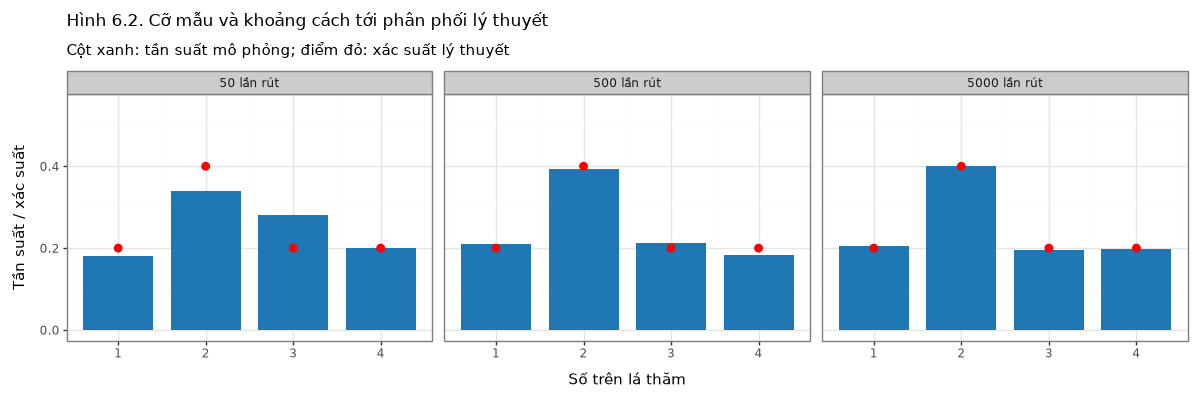

In [4]:
bang_tan_suat = []
bang_ly_thuyet = []
for m, ts in zip([50, 500, 5000], tan_suat_hop):
    bang_tan_suat.append(pd.DataFrame({'x': x_hop, 'p': ts, 'Co_mau': f'{m} lần rút'}))
    bang_ly_thuyet.append(pd.DataFrame({'x': x_hop, 'p': p_hop, 'Co_mau': f'{m} lần rút'}))
bang_tan_suat = pd.concat(bang_tan_suat, ignore_index=True)
bang_ly_thuyet = pd.concat(bang_ly_thuyet, ignore_index=True)
thu_tu_co_mau = ['50 lần rút', '500 lần rút', '5000 lần rút']
for bang in [bang_tan_suat, bang_ly_thuyet]:
    bang['Co_mau'] = pd.Categorical(bang['Co_mau'], categories=thu_tu_co_mau, ordered=True)
bieu_do = (p9.ggplot(bang_tan_suat, p9.aes('x', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.geom_point(data=bang_ly_thuyet, color='red', size=2.6)
    + p9.facet_wrap('Co_mau', nrow=1)
    + p9.scale_x_continuous(breaks=x_hop)
    + p9.coord_cartesian(ylim=(0, 0.55))
    + p9.labs(x='Số trên lá thăm', y='Tần suất / xác suất',
              title='Hình 6.2. Cỡ mẫu và khoảng cách tới phân phối lý thuyết',
              subtitle='Cột xanh: tần suất mô phỏng; điểm đỏ: xác suất lý thuyết')
    + p9.theme(figure_size=(12, 4)))
bieu_do.show()

Khi số lần rút tăng, tần suất thường gần xác suất hơn. Nhưng độ lệch không nhất thiết giảm sau **mỗi** lần thêm dữ liệu. Xác suất 0,4 nói về cơ chế rút và tần suất dài hạn; nó không hứa trước kết quả của một mẫu nhỏ.

*Thử thay đổi.* Đổi danh sách cỡ mẫu `[50, 500, 5000]` trong hai ô trên, hoặc đổi seed ở ô thiết lập rồi chạy lại từ đầu. Chỉ ra cột nào cao hơn lý thuyết, cột nào thấp hơn. Độ lệch mô phỏng không phải bằng chứng rằng hộp đã thay đổi.

### Ví dụ 2 — Tổng hai xúc xắc

Gieo độc lập hai xúc xắc cân đối. Một kết quả là cặp có thứ tự $(a,b)$ với $a,b\in\{1,\ldots,6\}$. Theo quy tắc nhân có $6\cdot6=36$ cặp, đồng khả năng. Gọi $X=a+b$.

**Bạn đoán trước:** tổng nào có xác suất lớn nhất?

- Tổng 2 chỉ ứng với cặp $(1,1)$, nên $P(X=2)=\frac1{36}$.
- Tổng 7 ứng với sáu cặp $(1,6),(2,5),\ldots,(6,1)$, nên $P(X=7)=\frac6{36}=\frac16$.

| Tổng $x$ | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Số cặp | 1 | 2 | 3 | 4 | 5 | 6 | 5 | 4 | 3 | 2 | 1 |

Không được chia đều xác suất cho 11 giá trị của tổng. Các **cặp** đồng khả năng, còn mỗi tổng gom một số cặp khác nhau.

**Code.** Ô dưới liệt kê 36 cặp để kiểm tra bảng, rồi mô phỏng 5.000 lần gieo.

- `itertools.product(range(1, 7), repeat=2)` liệt kê 36 cặp. `(cap_xuc_xac.sum(axis=1) == k).mean()` là tỉ lệ cặp có tổng $k$, tức xác suất chính xác.
- `rng.integers(1, 7, size=(5000, 2))` sinh 5.000 hàng, mỗi hàng một cặp. Cận trên 7 không được lấy, nên các số chạy từ 1 đến 6.
- `sum(axis=1)` cộng theo hàng, ra tổng của từng lần gieo.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `y='tan_suat'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

Mảng mô phỏng có dạng: (5000, 2)
Tần suất tổng bằng 7: 0.161
Xác suất tổng bằng 7: 0.1667


,Tổng,Số cặp,Lý thuyết,Tần suất
0,2,1,0.027778,0.0274
1,3,2,0.055556,0.0562
2,4,3,0.083333,0.0888
3,5,4,0.111111,0.1148
4,6,5,0.138889,0.1410
5,7,6,0.166667,0.1610
6,8,5,0.138889,0.1380
7,9,4,0.111111,0.1126
8,10,3,0.083333,0.0876
9,11,2,0.055556,0.0484


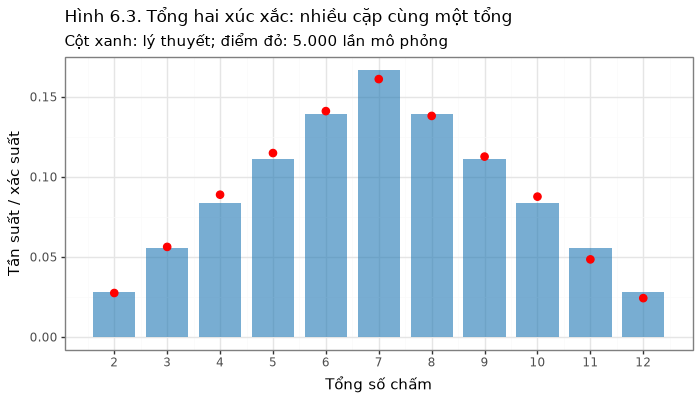

In [5]:
cap_xuc_xac = np.array(list(itertools.product(range(1, 7), repeat=2)))
x_dice = np.arange(2, 13)
p_dice = np.array([(cap_xuc_xac.sum(axis=1) == k).mean() for k in x_dice])
gieo_hai_xuc_xac = rng.integers(1, 7, size=(5000, 2))
tong_dice = gieo_hai_xuc_xac.sum(axis=1)
f_dice = np.array([(tong_dice == k).mean() for k in x_dice])
print('Mảng mô phỏng có dạng:', gieo_hai_xuc_xac.shape)
print('Tần suất tổng bằng 7:', round((tong_dice == 7).mean(), 4))
print('Xác suất tổng bằng 7:', round(6 / 36, 4))
display(pd.DataFrame({'Tổng': x_dice, 'Số cặp': np.rint(36*p_dice).astype(int),
                      'Lý thuyết': p_dice, 'Tần suất': f_dice}))

bang_dice = pd.DataFrame({'x': x_dice, 'p': p_dice, 'tan_suat': f_dice})
bieu_do = (p9.ggplot(bang_dice, p9.aes('x', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4', alpha=0.6)
    + p9.geom_point(p9.aes(y='tan_suat'), color='red', size=2.5)
    + p9.scale_x_continuous(breaks=x_dice)
    + p9.labs(x='Tổng số chấm', y='Tần suất / xác suất',
              title='Hình 6.3. Tổng hai xúc xắc: nhiều cặp cùng một tổng',
              subtitle='Cột xanh: lý thuyết; điểm đỏ: 5.000 lần mô phỏng'))
bieu_do.show()

Tần suất mô phỏng của tổng 7 ở gần $\frac16\approx0{,}1667$ nhưng không bằng đúng.

**Tự kiểm tra.** Vì sao 2 và 12 có cùng xác suất? Vì mỗi tổng ứng với đúng một cặp. Vì sao 6 và 8 có cùng xác suất? Vì mỗi tổng ứng với năm cặp. Tính đối xứng này đến từ cơ chế gieo, không phụ thuộc vào việc một mẫu mô phỏng có đối xứng hay không.

### Khi chỉ gieo 50 lần (Hình 6.4)

STAT 20 §3.4.4.4–3.4.4.5 đặt biểu đồ lý thuyết cạnh tần suất của 50 lần gieo. Ở đây 50 lần gieo là **50 kết quả đầu của mô phỏng ở trên** (`tong_dice[:50]`), nên khác mẫu trong bản dịch. Mẫu nhỏ có thể trông lệch nhiều, dù cơ chế vẫn là hai xúc xắc cân đối, độc lập.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p', fill='Loai'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

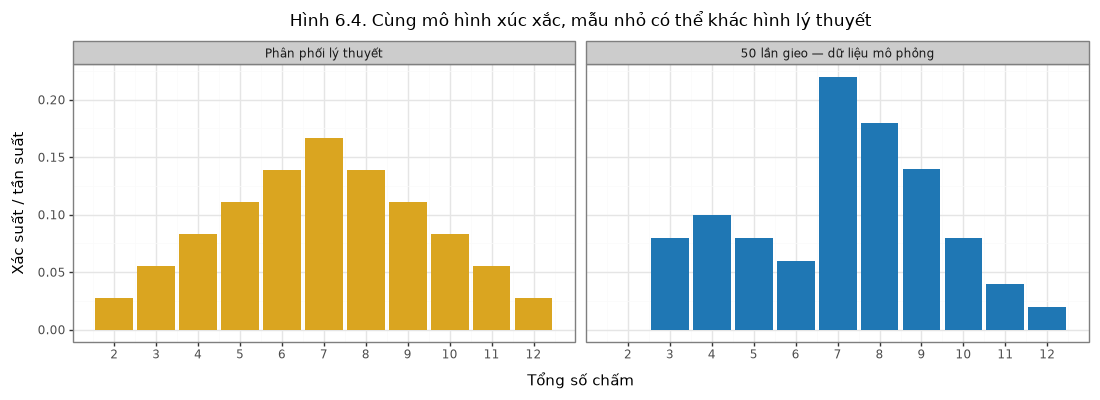

In [6]:
f_dice_50 = np.array([(tong_dice[:50] == k).mean() for k in x_dice])

bang_dice_nho = pd.concat([
    pd.DataFrame({'x': x_dice, 'p': p_dice, 'Loai': 'Phân phối lý thuyết'}),
    pd.DataFrame({'x': x_dice, 'p': f_dice_50, 'Loai': '50 lần gieo — dữ liệu mô phỏng'})],
    ignore_index=True)
bang_dice_nho['Loai'] = pd.Categorical(bang_dice_nho['Loai'],
    categories=['Phân phối lý thuyết', '50 lần gieo — dữ liệu mô phỏng'], ordered=True)
bieu_do = (p9.ggplot(bang_dice_nho, p9.aes('x', 'p', fill='Loai'))
    + p9.geom_col(width=0.9, show_legend=False)
    + p9.scale_fill_manual(values={'Phân phối lý thuyết': 'goldenrod',
                                    '50 lần gieo — dữ liệu mô phỏng': '#1f77b4'})
    + p9.facet_wrap('Loai', nrow=1)
    + p9.scale_x_continuous(breaks=x_dice)
    + p9.labs(x='Tổng số chấm', y='Xác suất / tần suất',
              title='Hình 6.4. Cùng mô hình xúc xắc, mẫu nhỏ có thể khác hình lý thuyết')
    + p9.theme(figure_size=(11, 4)))
bieu_do.show()

Với 50 lần gieo, mỗi cột tăng theo bội số $\frac1{50}=0{,}02$. Mẫu có nhiều tổng 7 hay thiếu một tổng nào đó cũng không làm đổi xác suất của lần gieo sau. Hai hình dùng cùng thang đo, để chiều cao so sánh được với nhau.

<a id="hoc-c70ccfbf"></a>
## 2. Quy tắc đếm

Ở Ví dụ 2 ta đếm 36 cặp bằng cách liệt kê. Khi số kết quả lớn, liệt kê không còn tiện; các quy tắc đếm giúp đếm có hệ thống. Mọi công thức trong mục này đều suy ra từ **quy tắc nhân**.

### Quy tắc nhân

Một việc gồm $r$ bước liên tiếp. Bước 1 có $k_1$ cách. Với **mỗi** cách làm các bước trước, bước $j$ luôn có $k_j$ cách. Khi đó số cách làm cả việc là

$$k_1\cdot k_2\cdots k_r.$$

Đọc là: số cách làm cả việc bằng tích số cách ở từng bước.

*Ví dụ.* Geni có 3 áo và 2 quần. Với mỗi áo đều có 2 cách chọn quần, nên có $3\cdot2=6$ bộ trang phục. Sơ đồ cây ở hình dưới có đúng sáu đường đi.

*Vì sao đúng.* Vẽ sơ đồ cây: gốc tách thành $k_1$ nhánh, mỗi nhánh lại tách thành $k_2$ nhánh, và cứ thế. Mỗi lá ở tầng cuối là một cách làm, và số lá bằng tích các số nhánh.

Hai điều cần để ý. Thứ nhất, **số** cách ở mỗi bước không được phụ thuộc vào lựa chọn ở bước trước (các lựa chọn cụ thể thì có thể khác nhau). Thứ hai, quy tắc đếm chỉ đếm; nó không nói các kết quả đồng khả năng. Chỉ khi cơ chế chọn cho chúng cùng khả năng, ta mới tính xác suất bằng tỉ số số kết quả.

**Quy tắc cộng.** Nếu các cách làm chia thành những nhóm không trùng nhau, tổng số cách bằng tổng số cách của các nhóm. Ví dụ: chọn một đại diện từ 12 sinh viên lớp A hoặc 15 sinh viên lớp B, không ai học cả hai lớp, có $12+15=27$ cách.

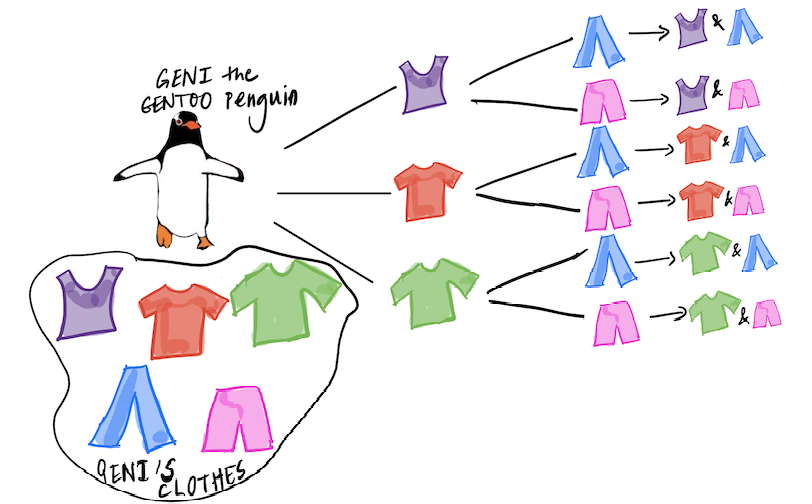

*Hình 2.1.* Geni chọn một áo và một quần: $3\cdot2=6$ bộ.  
*Nguồn ảnh: bản dịch STAT 20, §3.4.2 (tệp gốc: `figures/stat20_geni_quy_tac_dem.png`).*

### Chỉnh hợp và tổ hợp: thứ tự có quan trọng không?

Hộp có năm lá chữ cái `C, R, A, T, E`. Rút 3 lá và ghép thành một "từ".

- **Có hoàn lại**, ghi thứ tự: mỗi lần có 5 khả năng, nên có $5\cdot5\cdot5=5^3=125$ từ. Từ `CCC` được phép.
- **Không hoàn lại**, ghi thứ tự: lần 1 có 5 khả năng, lần 2 còn 4, lần 3 còn 3, nên có $5\cdot4\cdot3=60$ từ. `CRA` và `CAR` là hai từ khác nhau.

Cách chọn thứ hai gọi là **chỉnh hợp**. Số cách chọn $k$ phần tử **có thứ tự**, không hoàn lại, từ $n$ phần tử phân biệt là

$$A_n^k=n(n-1)\cdots(n-k+1)=\frac{n!}{(n-k)!},\qquad 0\le k\le n.$$

Ở đây $n!=n(n-1)\cdots2\cdot1$, đọc là *n giai thừa*, và quy ước $0!=1$. Khi $k=n$, ta được $n!$ cách xếp $n$ phần tử thành một hàng (**hoán vị**).

Nếu chỉ quan tâm **nhóm** ba chữ được lấy, thì sáu từ `CRA, CAR, RCA, RAC, ACR, ARC` là cùng một nhóm $\{C,R,A\}$. Mỗi nhóm 3 chữ bị đếm $3!=6$ lần, nên có $60/6=10$ nhóm. Đó là **tổ hợp**:

$$\binom nk=\frac{n!}{k!\,(n-k)!}.$$

Đọc $\binom nk$ là *n chọn k*: số cách chọn một nhóm $k$ phần tử từ $n$ phần tử, không tính thứ tự. Mỗi nhóm có $k!$ thứ tự, nên số tổ hợp bằng số chỉnh hợp chia cho $k!$. Ví dụ: chia 5 lá từ bộ bài 52 lá có $\binom{52}{5}=2\,598\,960$ tay bài. Trong Python, `math.comb(n, k)` tính $\binom nk$ chính xác.

**Có thứ tự hay không?** Đổi chỗ hai phần tử được chọn. Nếu kết quả thay đổi (ví dụ đổi vai chủ tịch và thư ký) thì có thứ tự: dùng chỉnh hợp. Nếu kết quả vẫn y nguyên (cùng một nhóm, cùng một tay bài) thì không: dùng tổ hợp.

*Ví dụ dùng đếm để tính xác suất.* Chia 5 lá từ bộ bài 52 lá; xác suất cả 5 lá đều là cơ là $\binom{13}5\big/\binom{52}5=1287/2\,598\,960\approx0{,}000495$. Tử và mẫu đều đếm **nhóm** lá, không tính thứ tự.

<details><summary><b>Nhắc lại</b> Giai thừa và cách viết của sách phổ thông</summary>

- $n!=1\cdot2\cdots n$; ví dụ $3!=6$, $4!=24$, $5!=120$. Quy ước $0!=1$.
- Sách phổ thông Việt Nam viết $\binom nk$ là $C_n^k$; ví dụ $C_5^3=\binom53=10$.
- Chỉnh hợp viết là $A_n^k$; ví dụ $A_5^3=60$.

</details>

<details><summary><b>Vì sao?</b> Chứng minh công thức chỉnh hợp và tổ hợp</summary>

*Chỉnh hợp.* Vị trí thứ nhất có $n$ lựa chọn, vị trí thứ hai còn $n-1$, …, vị trí thứ $k$ còn $n-k+1$. Theo quy tắc nhân có $n(n-1)\cdots(n-k+1)$ cách. Nhân cả tử và mẫu với $(n-k)!$ được $\dfrac{n!}{(n-k)!}$.

*Vì sao $0!=1$.* Để $A_n^n=\dfrac{n!}{0!}$ vẫn bằng $n!$, phải có $0!=1$.

*Tổ hợp.* Đếm số cách chọn **có thứ tự** theo hai cách.

- Cách 1: có $A_n^k=\dfrac{n!}{(n-k)!}$ cách.
- Cách 2: trước hết chọn **nhóm** $k$ phần tử ($\binom nk$ cách), rồi xếp nhóm đó theo thứ tự ($k!$ cách). Theo quy tắc nhân có $\binom nk\cdot k!$ cách.

Hai cách đếm cùng một thứ, nên
$$\binom nk\cdot k!=\frac{n!}{(n-k)!}\quad\Longrightarrow\quad\binom nk=\frac{n!}{k!\,(n-k)!}.\ \blacksquare$$

</details>

**Bạn đoán trước:** giải thích bằng lời vì sao 60 và 10 đều đúng nhưng trả lời hai câu hỏi khác nhau. Ô dưới liệt kê bằng `itertools`: `product` (có hoàn lại, có thứ tự), `permutations` (không hoàn lại, có thứ tự), `combinations` (không hoàn lại, không thứ tự).

In [7]:
chu_cai = ['C', 'R', 'A', 'T', 'E']
co_hoan_lai = list(itertools.product(chu_cai, repeat=3))
khong_hoan_lai = list(itertools.permutations(chu_cai, 3))
tap_con = list(itertools.combinations(chu_cai, 3))
print('Có hoàn lại, có thứ tự:', len(co_hoan_lai), '= 5^3')
print('Không hoàn lại, có thứ tự:', len(khong_hoan_lai), '= 5·4·3')
print('Không hoàn lại, không thứ tự:', len(tap_con), '= C(5,3)')
print('Các tập con:', tap_con)
print('Số bộ 5 lá bài:', f'{comb(52, 5):,}')
assert len(khong_hoan_lai) == factorial(3) * len(tap_con)

Có hoàn lại, có thứ tự: 125 = 5^3
Không hoàn lại, có thứ tự: 60 = 5·4·3
Không hoàn lại, không thứ tự: 10 = C(5,3)
Các tập con: [('C', 'R', 'A'), ('C', 'R', 'T'), ('C', 'R', 'E'), ('C', 'A', 'T'), ('C', 'A', 'E'), ('C', 'T', 'E'), ('R', 'A', 'T'), ('R', 'A', 'E'), ('R', 'T', 'E'), ('A', 'T', 'E')]
Số bộ 5 lá bài: 2,598,960


Kết quả: 125, 60 và 10 từ. Lệnh `assert` cuối ô kiểm tra $60=3!\cdot10$.

### Các tính chất của $\binom nk$

| Tính chất | Đọc thành lời | Ví dụ |
|---|---|---|
| $\binom nk=\binom n{n-k}$ | chọn $k$ phần tử để lấy cũng là chọn $n-k$ phần tử để bỏ | $\binom53=\binom52=10$ |
| $\binom nk=\binom{n-1}{k-1}+\binom{n-1}k$ | tam giác Pascal | $\binom52=\binom41+\binom42=4+6$ |
| $\sum_{k=0}^n\binom nk=2^n$ | tổng một hàng của tam giác Pascal | $1+3+3+1=2^3$ |
| số dãy gồm $k$ chữ S và $n-k$ chữ F là $\binom nk$ | chọn $k$ vị trí cho chữ S | $n=4$, $k=2$: SSFF, SFSF, SFFS, FSSF, FSFS, FFSS |

Tính chất cuối là cầu nối sang phân phối nhị thức ở mục 5: số chuỗi có đúng $k$ lần thành công trong $n$ lần thử là $\binom nk$. Phân phối siêu bội cũng dùng tổ hợp, vì mẫu là một **nhóm** lá thăm. Hai ứng dụng dùng cùng cách đếm, nhưng cơ chế thử khác nhau.

**Nhị thức Newton.** Với mọi số $a$, $b$ và số nguyên $n\ge0$:

$$(a+b)^n=\sum_{k=0}^n\binom nk a^k b^{n-k}.$$

Ví dụ $(a+b)^2=a^2+2ab+b^2$; các hệ số $1,2,1$ là hàng $n=2$ của tam giác Pascal.

<details><summary><b>Vì sao?</b> Chứng minh các tính chất và nhị thức Newton</summary>

*Đối xứng.* Mỗi cách chọn $k$ phần tử để lấy ứng với đúng một cách chọn $n-k$ phần tử để bỏ lại, nên hai số đếm bằng nhau.

*Tam giác Pascal.* Đánh dấu một phần tử, gọi là An. Mỗi nhóm $k$ phần tử hoặc có An, hoặc không, và hai trường hợp không trùng nhau. Nhóm có An: chọn thêm $k-1$ phần tử từ $n-1$ phần tử còn lại, có $\binom{n-1}{k-1}$ cách. Nhóm không có An: chọn cả $k$ phần tử từ $n-1$ phần tử còn lại, có $\binom{n-1}k$ cách. Cộng hai trường hợp (quy tắc cộng).

*Tổng một hàng.* Vế trái đếm mọi tập con của một tập $n$ phần tử, chia theo kích thước $k$. Vế phải đếm cùng thứ đó: mỗi phần tử có 2 lựa chọn, lấy hoặc không lấy, nên có $2^n$ tập con.

*Số dãy S/F.* Một dãy gồm $k$ chữ S và $n-k$ chữ F được xác định khi biết $k$ vị trí nào mang chữ S. Có $\binom nk$ cách chọn $k$ vị trí từ $n$ vị trí.

*Nhị thức Newton.* Viết $(a+b)^n=(a+b)(a+b)\cdots(a+b)$ với $n$ thừa số. Khi khai triển, mỗi số hạng được tạo bằng cách chọn $a$ hoặc $b$ từ **mỗi** thừa số rồi nhân lại. Số hạng $a^kb^{n-k}$ xuất hiện mỗi khi chọn $a$ ở đúng $k$ thừa số; theo tính chất số dãy S/F, có $\binom nk$ cách chọn như vậy. $\blacksquare$

</details>

**Lỗi hay gặp khi đếm.**

- Tử số đếm có thứ tự, mẫu số đếm không thứ tự. Khi tính xác suất bằng đếm, tử và mẫu phải đếm theo **cùng một cách**.
- Đếm trùng. "Chọn 2 người có ít nhất 1 nữ" mà tính bằng "chọn 1 nữ, rồi chọn 1 người bất kỳ trong số còn lại" thì nhóm 2 nữ bị đếm hai lần. Dùng phần bù: tổng số nhóm trừ số nhóm toàn nam.
- Nhầm $\binom nk$ với $n^k$. $n^k$ là số cách chọn có hoàn lại, có thứ tự.

<a id="hoc-r6-003"></a>
## 3. Biến ngẫu nhiên gán con số cho kết quả

### Từ biến cố đến biến ngẫu nhiên: một lượt roulette

Ở Tuần 05, bánh xe roulette kiểu Mỹ có 38 ô đồng khả năng: 18 đỏ, 18 đen, 2 xanh. Đặt cược 1 USD vào đỏ. Bóng rơi vào ô đỏ thì bạn lời 1 USD; nếu không thì mất 1 USD.

Gọi $X$ là tiền lời. Mỗi kết quả trong 38 ô được gán **một con số**:

- $X=+1$ khi bóng rơi vào một trong 18 ô đỏ, nên $P(X=1)=\frac{18}{38}$;
- $X=-1$ khi bóng rơi vào một trong 20 ô đen hoặc xanh, nên $P(X=-1)=\frac{20}{38}$.

Ba mươi tám kết quả gom lại thành chỉ hai giá trị. Phân phối của một biến ngẫu nhiên luôn được lập theo ba bước:

1. liệt kê không gian mẫu và xác suất của từng kết quả;
2. với mỗi giá trị $x$, gom mọi kết quả cho $X=x$;
3. cộng xác suất của các kết quả đã gom.

### Ví dụ 3 — Ba lần tung đồng xu

Tung một đồng xu cân đối ba lần độc lập; `H` là ngửa, `T` là sấp. Mỗi kết quả $\omega$ là một chuỗi có thứ tự, chẳng hạn `HHT`. Đặt $X$ là số mặt ngửa trong chuỗi. Khi đó $X(\mathrm{HHT})=2$ và $X(\mathrm{TTT})=0$.

Một **biến ngẫu nhiên** là một hàm

$$X:\Omega\longrightarrow\mathbb R.$$

Đọc là: $X$ đi từ không gian mẫu $\Omega$ vào tập số thực $\mathbb R$. Mỗi kết quả $\omega\in\Omega$ được gán một số thực $X(\omega)$. Chữ hoa $X$ chỉ đại lượng khi chưa biết kết quả; chữ thường $x$ chỉ một giá trị cụ thể.

Biến cố $\{X=2\}$, đọc là *biến cố X bằng 2*, là tập $\{\mathrm{HHT},\mathrm{HTH},\mathrm{THH}\}$. Nhiều kết quả có thể được gán cùng một số. Muốn có $P(X=2)$, cộng xác suất của mọi kết quả được gán số 2.

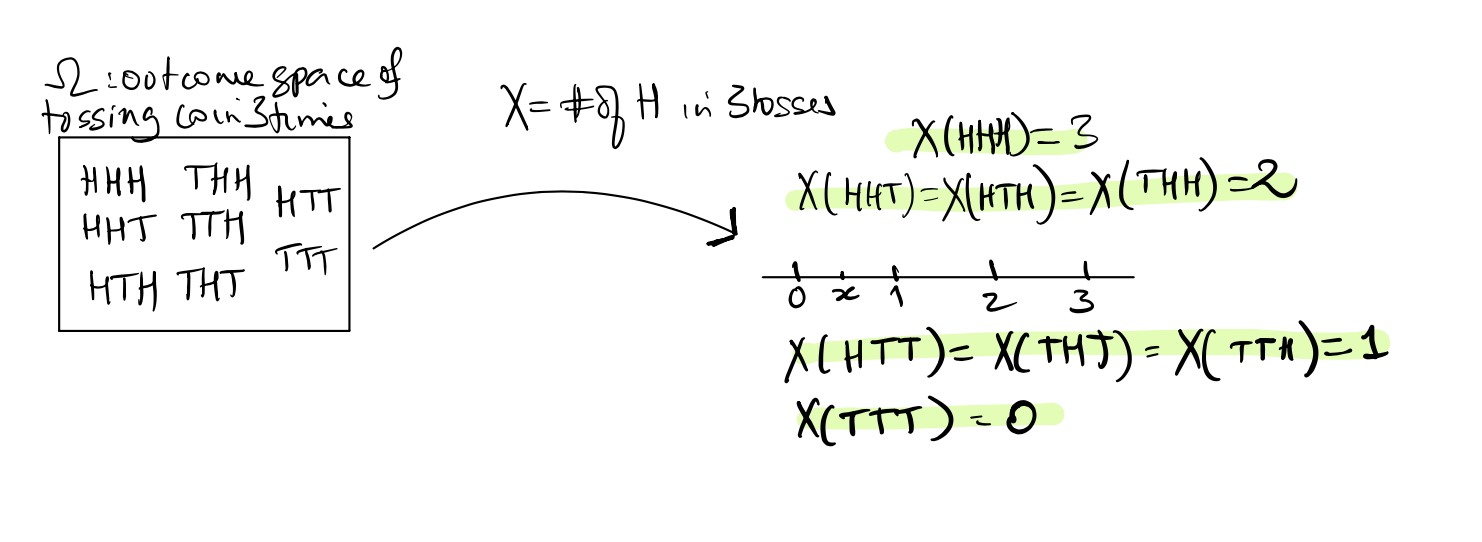

*Hình 3.1.* Mỗi chuỗi tung đồng xu được gán vào số mặt ngửa của nó; nhiều chuỗi có thể cùng chỉ vào một số.  
*Nguồn ảnh: bản dịch STAT 20, §4.1, Figure 5 (tệp gốc: `figures/stat20_anh_xa_bien_ngau_nhien.png`).*

**Code.** Ô dưới lập bảng tám chuỗi. `itertools.product('HT', repeat=3)` liệt kê các chuỗi; `.str.count('H')` đếm số chữ H, tức giá trị của $X$; mỗi chuỗi có xác suất $\frac18$.

In [8]:
omega_xu = [''.join(chuoi) for chuoi in itertools.product('HT', repeat=3)]
bang_xu = pd.DataFrame({'Kết quả ω': omega_xu})
bang_xu['X = số ngửa'] = bang_xu['Kết quả ω'].str.count('H')
bang_xu['Xác suất của ω'] = 1 / 8
display(bang_xu)
print('Biến cố {X=2}:', bang_xu.loc[bang_xu['X = số ngửa'] == 2, 'Kết quả ω'].tolist())

,Kết quả ω,X = số ngửa,Xác suất của ω
0,HHH,3,0.125
1,HHT,2,0.125
2,HTH,2,0.125
3,HTT,1,0.125
4,THH,2,0.125
5,THT,1,0.125
6,TTH,1,0.125
7,TTT,0,0.125


Biến cố {X=2}: ['HHT', 'HTH', 'THH']


### Rời rạc và liên tục

Biến ngẫu nhiên **rời rạc** nhận hữu hạn hoặc vô hạn đếm được các giá trị. Số yêu cầu đến máy chủ trong một phút, số khách đến ATM trong một giờ hay số lỗi chính tả đều là số đếm. Biến rời rạc có thể nhận vô hạn giá trị: số lần tung tới khi gặp mặt ngửa đầu tiên là $1,2,3,\ldots$, và nó vẫn rời rạc.

Thời gian phản hồi của một dịch vụ, chiều cao một người hay lượng mưa trong ngày thường được mô hình hóa bằng biến ngẫu nhiên **liên tục**, nhận giá trị trên cả một khoảng của trục số. Số đo bị làm tròn không biến thời gian thành một số đếm. Buổi này tập trung vào biến rời rạc; biến liên tục học ở Tuần 07.

### Ví dụ 4 — Hàm khối xác suất của số mặt ngửa

Tám chuỗi trong bảng trên có cùng xác suất $\frac18$. Có 1 chuỗi không có mặt ngửa, 3 chuỗi có một ngửa, 3 chuỗi có hai ngửa và 1 chuỗi có ba ngửa:

| $x$ | 0 | 1 | 2 | 3 |
|---|---:|---:|---:|---:|
| $p_X(x)$ | $1/8$ | $3/8$ | $3/8$ | $1/8$ |

**Phân phối xác suất** của một biến ngẫu nhiên rời rạc gồm các giá trị nó có thể nhận và xác suất tương ứng. **Hàm khối xác suất** (probability mass function, PMF) ghi thông tin đó thành một hàm:

$$p_X(x)=P(X=x).$$

Đọc $p_X(x)$ là *hàm khối xác suất của X tại x*. Gọi $S$ là tập các giá trị $X$ có thể nhận. PMF luôn thỏa

$$0\le p_X(x)\le1,\qquad\sum_{x\in S}p_X(x)=1.$$

Đọc là: mỗi khối xác suất nằm giữa 0 và 1, và tổng mọi khối bằng 1. Ở ví dụ này $S=\{0,1,2,3\}$; ngoài $S$, PMF bằng 0.

<details><summary><b>Vì sao?</b> Tổng các khối xác suất bằng 1</summary>

*Bước 1.* $p_X(x)$ là xác suất của biến cố $\{X=x\}$, nên không âm (tiên đề 1).

*Bước 2.* Mỗi kết quả của phép thử cho $X$ đúng **một** giá trị. Vì vậy các biến cố $\{X=x\}$ ứng với các giá trị $x$ khác nhau thì rời nhau, và hợp của chúng là $\Omega$.

*Bước 3.* Theo tiên đề 3 rồi tiên đề 2, tổng các xác suất bằng $P(\Omega)=1$. $\blacksquare$

Khi $X$ có vô số giá trị, như phân phối Poisson ở mục 6, bước 3 cần dạng "dãy vô hạn" của tiên đề 3. Mọi bảng phân phối bạn tự lập đều phải có tổng bằng 1; nếu không, chắc chắn đã có lỗi.

</details>

Muốn tính xác suất của một biến cố gồm nhiều giá trị, cộng các khối tương ứng. Ví dụ: $P(X\ge2)=p_X(2)+p_X(3)=\frac38+\frac18=\frac12$.

**Code.** `p_xu` là tỉ lệ chuỗi có $X=x$ trong bảng tám chuỗi; `p_xu[x_xu >= 2].sum()` cộng các khối có $x\ge2$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,x,p_X(x)
0,0,0.125
1,1,0.375
2,2,0.375
3,3,0.125


P(X≥2) = 0.5


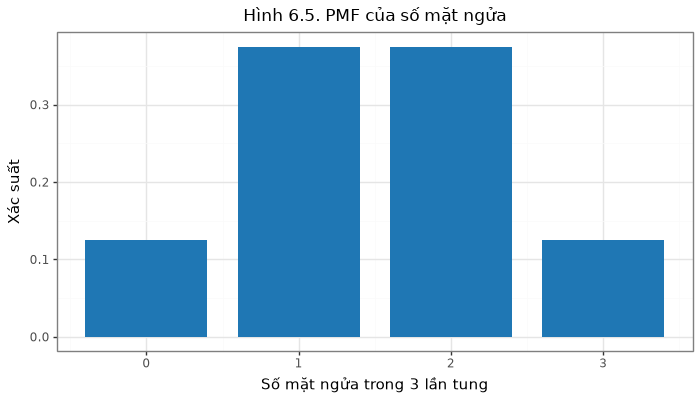

In [9]:
x_xu = np.arange(4)
p_xu = np.array([(bang_xu['X = số ngửa'] == x).mean() for x in x_xu])
display(pd.DataFrame({'x': x_xu, 'p_X(x)': p_xu}))
print('P(X≥2) =', p_xu[x_xu >= 2].sum())
assert np.isclose(p_xu.sum(), 1)

bang_pmf_xu = pd.DataFrame({'x': x_xu, 'p': p_xu})
bieu_do = (p9.ggplot(bang_pmf_xu, p9.aes('x', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.scale_x_continuous(breaks=x_xu)
    + p9.labs(x='Số mặt ngửa trong 3 lần tung', y='Xác suất',
              title='Hình 6.5. PMF của số mặt ngửa'))
bieu_do.show()

### Ví dụ 5 — Số ngửa trừ số sấp

Tung một đồng xu cân đối ba lần độc lập, giữ thứ tự kết quả. Đặt $X$ bằng số mặt ngửa **trừ** số mặt sấp.

1. Liệt kê mọi giá trị mà $X$ có thể nhận.
2. Với mỗi giá trị, liệt kê những kết quả tương ứng của phép thử.
3. Tính xác suất của từng giá trị. $X$ có thể bằng 0 không?

*Gợi ý.* Viết $X$ theo số mặt ngửa $N$ trước khi nhìn đáp án. Cách này tránh bỏ sót, hoặc tự thêm một giá trị không thể xảy ra.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1: viết $X$ theo số ngửa $N$.* Số sấp là $3-N$, nên $X=N-(3-N)=2N-3$.

*Bước 2: các giá trị.* $N$ nhận $0,1,2,3$, nên $X$ nhận $-3,-1,1,3$.

*Bước 3: gom kết quả và cộng xác suất.* Mỗi chuỗi có xác suất $\frac18$, nên mỗi hàng nhận xác suất bằng số chuỗi trong hàng chia cho 8.

| $x$ | Kết quả tương ứng | $P(X=x)$ |
|---:|---|---:|
| $-3$ | TTT | $1/8$ |
| $-1$ | HTT, THT, TTH | $3/8$ |
| $1$ | HHT, HTH, THH | $3/8$ |
| $3$ | HHH | $1/8$ |

*Câu 3.* $X=0$ đòi hỏi $2N-3=0$, tức $N=1{,}5$: không thể có 1,5 mặt ngửa. Vậy $P(X=0)=0$. Biến rời rạc không bắt buộc phải nhận mọi số nguyên nằm giữa giá trị nhỏ nhất và lớn nhất.

</details>

In [10]:
bang_xu['Ngửa trừ sấp'] = 2 * bang_xu['X = số ngửa'] - 3
bang_hieu = bang_xu.groupby('Ngửa trừ sấp').agg(
    ket_qua=('Kết quả ω', lambda s: ', '.join(s)),
    xac_suat=('Xác suất của ω', 'sum'))
display(bang_hieu)
print('P(X=0) =', (bang_xu['Ngửa trừ sấp'] == 0).mean())

,ket_qua,xac_suat
Ngửa trừ sấp,,
-3,TTT,0.125
-1,"HTT, THT, TTH",0.375
1,"HHT, HTH, THH",0.375
3,HHH,0.125


P(X=0) = 0.0


Ô code trên làm lại bảng đáp án bằng `groupby` (Tuần 03): gom các chuỗi theo giá trị "Ngửa trừ sấp", nối tên các chuỗi bằng `', '.join`, và cộng cột xác suất bằng `'sum'`.

Số ngửa trừ số sấp có cùng các khối $\frac18,\frac38,\frac38,\frac18$ như số ngửa, nhưng các khối nằm ở những giá trị khác. Khi ghi một phân phối, đừng chỉ ghi các xác suất mà quên ghi **giá trị nào** mang xác suất đó.

### Đặt cược vào đỏ sáu lượt

Quay lại roulette. Mô hình giả sử 38 ô đồng khả năng và các lượt quay độc lập. Cược 1 USD vào đỏ: trúng thì nhận lại 1 USD tiền gốc và lời thêm 1 USD; trượt thì mất 1 USD. **Lãi ròng** của một lượt là $+1$ hoặc $-1$ USD, không phải $+2$ hoặc $0$.

Gọi $N$ là số lượt thắng khi cược vào đỏ sáu lượt, và $L$ là tổng lãi ròng. Giống Ví dụ 5:

$$L=N-(6-N)=2N-6.$$

$N$ nhận $0,1,\ldots,6$ nên $L$ nhận $-6,-4,-2,0,2,4,6$. Đây là một biến ngẫu nhiên, vì mỗi chuỗi kết quả sáu lượt được gán một tổng lãi cụ thể. Xác suất thắng một lượt là $\frac{18}{38}$, thua là $\frac{20}{38}$: chỉ có hai loại kết quả không làm chúng đồng khả năng.

**Code.** Ô dưới mô phỏng 10.000 người chơi, mỗi người sáu lượt.

- `rng.random((10000, 6)) < p_do`: mỗi ô là một lượt. Một số ngẫu nhiên đều trên $[0,1)$ nhỏ hơn $\frac{18}{38}$ với xác suất đúng bằng $\frac{18}{38}$, nên `True` nghĩa là thắng.
- `thang.sum(axis=1)` đếm số lượt thắng $N$ của mỗi người; `2 * so_thang - so_luot` là $L$.

Mục 5 sẽ cho công thức chính xác của bảng lãi này.

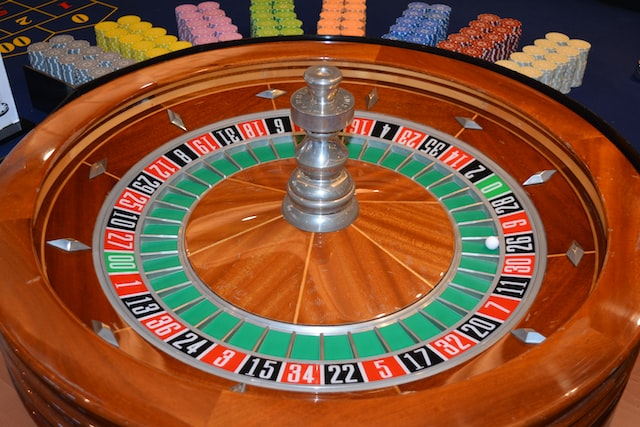

*Hình 3.3.* Bánh xe roulette trong ví dụ đặt cược vào đỏ.  
*Nguồn ảnh: bản dịch STAT 20, §4.2, Figure 6 (tệp gốc: `figures/stat20_roulette.jpg`).*

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,Lãi ròng (USD),Tần suất mô phỏng
0,-6,0.0220
1,-4,0.1182
2,-2,0.2608
3,0,0.3121
4,2,0.2016
5,4,0.0745
6,6,0.0108


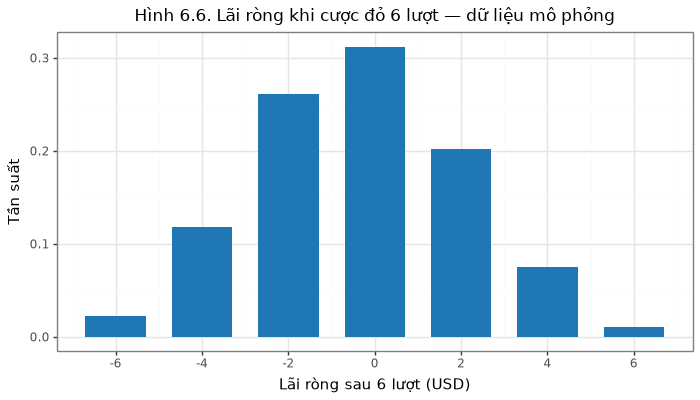

In [11]:
so_luot = 6
so_lan_lap = 10000
p_do = 18 / 38
thang = rng.random((so_lan_lap, so_luot)) < p_do
so_thang = thang.sum(axis=1)
lai_rong = 2 * so_thang - so_luot
gia_tri_lai = np.arange(-6, 7, 2)
ts_lai = np.array([(lai_rong == k).mean() for k in gia_tri_lai])
display(pd.DataFrame({'Lãi ròng (USD)': gia_tri_lai, 'Tần suất mô phỏng': ts_lai}))

bang_lai_rong = pd.DataFrame({'x': gia_tri_lai, 'p': ts_lai})
bieu_do = (p9.ggplot(bang_lai_rong, p9.aes('x', 'p'))
    + p9.geom_col(width=1.4, fill='#1f77b4')
    + p9.scale_x_continuous(breaks=gia_tri_lai)
    + p9.labs(x='Lãi ròng sau 6 lượt (USD)', y='Tần suất',
              title='Hình 6.6. Lãi ròng khi cược đỏ 6 lượt — dữ liệu mô phỏng'))
bieu_do.show()

Lãi 0 nghĩa là thắng 3, thua 3; lãi 6 nghĩa là thắng cả sáu lượt. Bảy mức lãi không có cùng xác suất $\frac17$: mỗi mức gom một số chuỗi thắng/thua khác nhau, và một lượt thắng hay thua cũng không đồng khả năng.

**Tự kiểm tra.** Thắng 4, thua 2 thì lãi ròng bằng bao nhiêu? Bằng $4-2=2$ USD. Tiền gốc nhận lại ở các lượt thắng không tạo thêm lãi. Lãi trung bình về dài hạn sẽ học ở Tuần 07.

<a id="hoc-074d33fe"></a>
## 4. Hàm phân phối tích lũy trả lời câu hỏi về ngưỡng

### Ví dụ 6 — Hai sản phẩm được kiểm tra độc lập

Mỗi sản phẩm đạt chuẩn với xác suất 0,8, độc lập với nhau. Gọi $X$ là số sản phẩm đạt chuẩn trong hai sản phẩm.

1. Không sản phẩm nào đạt: hai lần trượt, $(0{,}2)^2=0{,}04$.
2. Đúng một sản phẩm đạt: đạt–trượt **hoặc** trượt–đạt. Hai trường hợp xung khắc, nên $2\cdot(0{,}8)(0{,}2)=0{,}32$.
3. Cả hai đạt: $(0{,}8)^2=0{,}64$.

| $x$ | 0 | 1 | 2 |
|---|---:|---:|---:|
| $p_X(x)$ | 0,04 | 0,32 | 0,64 |

Muốn biết xác suất **không quá một** sản phẩm đạt, cộng $0{,}04+0{,}32=0{,}36$. Câu hỏi "không quá ngưỡng $t$" gặp rất thường xuyên, nên ta đặt tên cho nó: **hàm phân phối tích lũy** (cumulative distribution function, CDF)

$$F_X(t)=P(X\le t)=\sum_{x\le t}p_X(x).$$

Đọc $F_X(t)$ là *hàm phân phối tích lũy của X tại t*: xác suất để $X$ không vượt quá ngưỡng $t$. Tổng lấy mọi giá trị $x$ không vượt quá $t$, **kể cả** giá trị bằng đúng $t$. Dù $X$ rời rạc, $F_X$ được định nghĩa với **mọi** số thực $t$.

### Lập CDF từng khoảng

Với Ví dụ 6:

$$
F_X(t)=\begin{cases}
0,&t<0,\\
0{,}04,&0\le t<1,\\
0{,}36,&1\le t<2,\\
1,&t\ge2.
\end{cases}
$$

Ví dụ: $F_X(1{,}5)=P(X\le1{,}5)=P(X=0)+P(X=1)=0{,}36$, vì $X$ không nhận giá trị nào giữa 1 và 1,5.

CDF có bốn tính chất:

1. không giảm: nếu $a<b$ thì $F_X(a)\le F_X(b)$;
2. nằm trong $[0,1]$, tiến về 0 khi $t\to-\infty$ và tiến về 1 khi $t\to+\infty$;
3. với $a<b$: $P(a<X\le b)=F_X(b)-F_X(a)$;
4. với biến rời rạc, đồ thị có dạng **bậc thang**; tại giá trị $x$ có khối dương, CDF nhảy lên đúng $p_X(x)$.

Ở tính chất 3, phép trừ bỏ toàn bộ xác suất tại và dưới $a$, nên đầu trái là dấu $<$, đầu phải là $\le$. Ví dụ: $P(0<X\le2)=F_X(2)-F_X(0)=1-0{,}04=0{,}96$, xác suất có ít nhất một sản phẩm đạt.

<details><summary><b>Vì sao?</b> Chứng minh các tính chất của CDF</summary>

*Tính chất 1.* Nếu $a<b$ thì $\{X\le a\}\subseteq\{X\le b\}$. Theo tính đơn điệu của xác suất (Tuần 05), $F_X(a)\le F_X(b)$.

*Tính chất 3.* Biến cố $\{X\le b\}$ là hợp của hai mảnh rời nhau $\{X\le a\}$ và $\{a<X\le b\}$. Theo tiên đề 3: $F_X(b)=F_X(a)+P(a<X\le b)$.

*Tính chất 4.* Áp dụng tính chất 3 với $a$ tiến sát $x$ từ bên trái: khoảng $(a,x]$ cuối cùng chỉ còn chứa giá trị $x$, nên độ nhảy bằng $P(X=x)$.

*Tính chất 2* cần khái niệm giới hạn; ở học phần này chỉ cần hiểu bằng trực giác. Ngưỡng rất thấp thì gần như không giá trị nào thỏa; ngưỡng rất cao thì gần như mọi giá trị đều thỏa. $\blacksquare$

</details>

CDF **liên tục bên phải**: tại điểm nhảy, giá trị của CDF là đầu **trên** của bước nhảy. Hình 6.7 dùng chấm đặc cho giá trị được lấy, vòng tròn rỗng cho giới hạn bên trái. Trong code, `p_sp.cumsum()` cộng dồn PMF thành CDF tại các điểm 0, 1, 2.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `y='F_trai'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_step` vẽ đường bậc thang; ở CDF, `direction="hv"` giữ giá trị sau điểm nhảy trên đoạn nằm ngang kế tiếp. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,x,p_X(x),F_X(x)
0,0,0.04,0.04
1,1,0.32,0.36
2,2,0.64,1.00


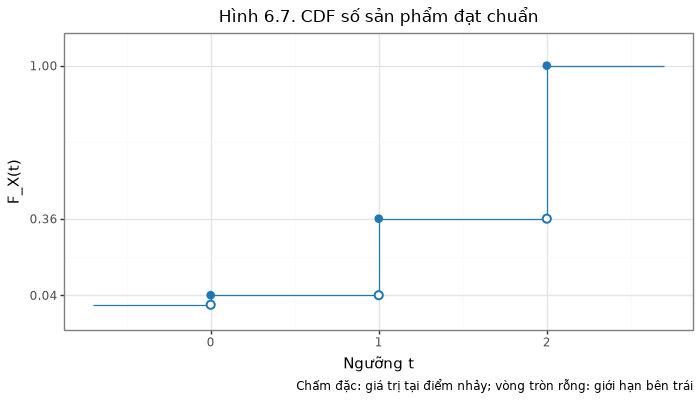

In [12]:
x_sp = np.array([0, 1, 2])
p_sp = np.array([0.04, 0.32, 0.64])
F_sp = p_sp.cumsum()
display(pd.DataFrame({'x': x_sp, 'p_X(x)': p_sp, 'F_X(x)': F_sp}))

duong_cdf_sp = pd.DataFrame({'x': [-0.7, 0, 1, 2, 2.7], 'F': [0, 0.04, 0.36, 1, 1]})
diem_cdf_sp = pd.DataFrame({'x': x_sp, 'F': F_sp, 'F_trai': np.r_[0, F_sp[:-1]]})
bieu_do = (p9.ggplot(duong_cdf_sp, p9.aes('x', 'F'))
    + p9.geom_step(direction='hv', color='#1f77b4')
    + p9.geom_point(data=diem_cdf_sp, size=2.5, color='#1f77b4', fill='#1f77b4')
    + p9.geom_point(data=diem_cdf_sp, mapping=p9.aes(y='F_trai'),
                    shape='o', size=2.5, color='#1f77b4', fill='white', stroke=0.8)
    + p9.scale_x_continuous(breaks=x_sp)
    + p9.scale_y_continuous(breaks=[0.04, 0.36, 1])
    + p9.coord_cartesian(ylim=(-0.05, 1.08))
    + p9.labs(x='Ngưỡng t', y='F_X(t)', title='Hình 6.7. CDF số sản phẩm đạt chuẩn',
              caption='Chấm đặc: giá trị tại điểm nhảy; vòng tròn rỗng: giới hạn bên trái'))
bieu_do.show()

Tại $t=1$, CDF bằng 0,36, không phải 0,04. Độ nhảy $0{,}36-0{,}04=0{,}32$ chính là xác suất đúng một sản phẩm đạt. Với ngưỡng 1,5, chưa thêm giá trị nào của $X$, nên $F_X(1{,}5)=F_X(1)=0{,}36$. Vì vậy CDF rời rạc có các đoạn nằm ngang.

### Ví dụ 7 — Tính xác suất chỉ từ CDF

Vẫn xét hai sản phẩm độc lập với xác suất đạt 0,8. PMF tại $0,1,2$ lần lượt là $0{,}04;\ 0{,}32;\ 0{,}64$.

Tính $P(X<2)$ và $P(X=1)$ chỉ bằng các giá trị của $F_X$. Trước khi tính, viết lại biến cố bằng các giá trị nguyên mà $X$ có thể nhận.

<details><summary>Đáp án và cách lập luận</summary>

*$P(X<2)$.* $X$ chỉ nhận $0,1,2$, nên "nhỏ hơn 2" là "không quá 1":
$$P(X<2)=P(X\le1)=F_X(1)=0{,}36.$$

*$P(X=1)$.* Xác suất tại 1 là độ nhảy của CDF tại 1:
$$P(X=1)=F_X(1)-F_X(0)=0{,}36-0{,}04=0{,}32.$$

Không dùng $F_X(2)$ cho $X<2$: giá trị đó gồm cả trường hợp hai sản phẩm đều đạt. Công thức $P(X=k)=F_X(k)-F_X(k-1)$ chỉ dùng khi $X$ nhận giá trị nguyên. Tổng quát, độ nhảy tại $x$ là $F_X(x)-F_X(x^-)$, trong đó $F_X(x^-)$ là giới hạn bên trái của $F_X$ tại $x$.

</details>

In [13]:
print('P(X<2) = F(1) =', round(F_sp[1], 2))
print('P(X=1) = F(1)-F(0) =', round(F_sp[1]-F_sp[0], 2))
print('P(0<X≤2) = F(2)-F(0) =', round(F_sp[2]-F_sp[0], 2))

P(X<2) = F(1) = 0.36
P(X=1) = F(1)-F(0) = 0.32
P(0<X≤2) = F(2)-F(0) = 0.96


### Ví dụ 8 — Sáu đường dây điện thoại

Một doanh nghiệp có sáu đường dây. Tại thời điểm quan sát, số đường đang được sử dụng là $X$, có PMF sau:

| $x$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|---:|
| $p_X(x)$ | 0,10 | 0,15 | 0,20 | 0,25 | 0,20 | 0,06 | 0,04 |

1. Tính xác suất nhiều nhất ba đường đang dùng.
2. Tính xác suất ít hơn ba đường đang dùng.
3. Tính xác suất có từ hai đến bốn đường **chưa** dùng, gồm cả hai đầu mút.
4. Lập $F_X$ cho mọi số thực và vẽ đồ thị.

*Gợi ý.* Biến trong bảng là số đường **đang dùng**. Ở câu 3, trước hết đổi điều kiện về đúng biến đó.

<details><summary>Đáp án và cách lập luận</summary>

1. *Nhiều nhất ba đường đang dùng* là $X\le3$: $0{,}10+0{,}15+0{,}20+0{,}25=0{,}70$.
2. *Ít hơn ba đường* là $X\le2$, không gồm 3: $0{,}10+0{,}15+0{,}20=0{,}45$.
3. *Từ hai đến bốn đường chưa dùng.* Gọi $Y=6-X$ là số đường chưa dùng. Điều kiện $2\le6-X\le4$. Trừ 6 ở mọi vế: $-4\le-X\le-2$. Nhân với $-1$ thì đổi chiều: $2\le X\le4$. Xác suất là $0{,}20+0{,}25+0{,}20=0{,}65$.
4. *Lập $F_X$:* cộng dồn PMF.
$$F_X(t)=\begin{cases} 0,&t<0,\\ 0{,}10,&0\le t<1,\\ 0{,}25,&1\le t<2,\\ 0{,}45,&2\le t<3,\\ 0{,}70,&3\le t<4,\\ 0{,}90,&4\le t<5,\\ 0{,}96,&5\le t<6,\\ 1,&t\ge6. \end{cases}$$

"Nhiều nhất ba" gồm giá trị 3; "ít hơn ba" thì không. Chênh lệch $0{,}70-0{,}45=0{,}25$ chính là xác suất có đúng ba đường đang dùng.

</details>

Ô dưới tính lại ba câu đầu và vẽ đồ thị CDF. Điều kiện câu 3 được viết trực tiếp theo số đường chưa dùng: `(6-x_dien_thoai >= 2) & (6-x_dien_thoai <= 4)`.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `y='F_trai'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_step` vẽ đường bậc thang; ở CDF, `direction="hv"` giữ giá trị sau điểm nhảy trên đoạn nằm ngang kế tiếp. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

Nhiều nhất 3: 0.7
Ít hơn 3: 0.45
Từ 2 đến 4 đường chưa dùng: 0.65


,x,p_X(x),F_X(x)
0,0,0.10,0.10
1,1,0.15,0.25
2,2,0.20,0.45
3,3,0.25,0.70
4,4,0.20,0.90
5,5,0.06,0.96
6,6,0.04,1.00


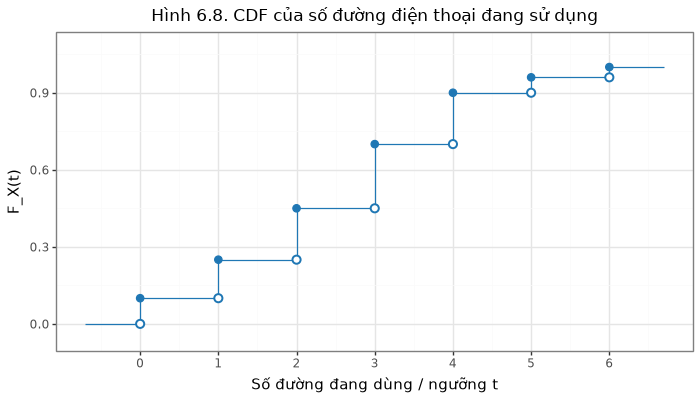

In [14]:
x_dien_thoai = np.arange(7)
p_dien_thoai = np.array([0.10, 0.15, 0.20, 0.25, 0.20, 0.06, 0.04])
F_dien_thoai = p_dien_thoai.cumsum()
assert np.isclose(p_dien_thoai.sum(), 1)
print('Nhiều nhất 3:', p_dien_thoai[x_dien_thoai <= 3].sum())
print('Ít hơn 3:', p_dien_thoai[x_dien_thoai < 3].sum())
print('Từ 2 đến 4 đường chưa dùng:', p_dien_thoai[(6-x_dien_thoai >= 2) & (6-x_dien_thoai <= 4)].sum())
display(pd.DataFrame({'x': x_dien_thoai, 'p_X(x)': p_dien_thoai, 'F_X(x)': F_dien_thoai}))

duong_cdf_dt = pd.DataFrame({'x': np.r_[-0.7, x_dien_thoai, 6.7],
                             'F': np.r_[0, F_dien_thoai, 1]})
diem_cdf_dt = pd.DataFrame({'x': x_dien_thoai, 'F': F_dien_thoai,
                            'F_trai': np.r_[0, F_dien_thoai[:-1]]})
bieu_do = (p9.ggplot(duong_cdf_dt, p9.aes('x', 'F'))
    + p9.geom_step(direction='hv', color='#1f77b4')
    + p9.geom_point(data=diem_cdf_dt, size=2.5, color='#1f77b4', fill='#1f77b4')
    + p9.geom_point(data=diem_cdf_dt, mapping=p9.aes(y='F_trai'),
                    shape='o', size=2.5, color='#1f77b4', fill='white', stroke=0.8)
    + p9.scale_x_continuous(breaks=x_dien_thoai)
    + p9.coord_cartesian(ylim=(-0.05, 1.08))
    + p9.labs(x='Số đường đang dùng / ngưỡng t', y='F_X(t)',
              title='Hình 6.8. CDF của số đường điện thoại đang sử dụng'))
bieu_do.show()

Độ nhảy tại 3 là $F_X(3)-F_X(2)=0{,}70-0{,}45=0{,}25$. Tổng mọi độ nhảy bằng 1. Nếu sửa một xác suất trong bảng, hãy kiểm tra tổng vẫn bằng 1 trước khi gọi bảng đó là PMF.

### Đổi câu hỏi sang $F$

Với biến rời rạc, $P(X<a)$ và $P(X\le a)$ khác nhau đúng một lượng $P(X=a)$. Bảng sau đổi các câu hỏi thường gặp sang $F$; cột cuối dùng khi $X$ chỉ nhận giá trị nguyên.

| Câu hỏi | Ký hiệu | Theo $F$ | Khi $X$ nguyên |
|---|---|---|---|
| không quá $a$, nhiều nhất $a$ | $P(X\le a)$ | $F(a)$ | $F(a)$ |
| ít hơn $a$ | $P(X<a)$ | $F(a)-P(X=a)$ | $F(a-1)$ |
| nhiều hơn $a$ | $P(X>a)$ | $1-F(a)$ | $1-F(a)$ |
| ít nhất $a$, không dưới $a$ | $P(X\ge a)$ | $1-F(a)+P(X=a)$ | $1-F(a-1)$ |
| từ $a$ đến $b$, gồm hai đầu | $P(a\le X\le b)$ | $F(b)-F(a)+P(X=a)$ | $F(b)-F(a-1)$ |

*Ví dụ.* Gieo một xúc xắc: $F(2)=P(X\le2)=\frac26$, nhưng $P(X<2)=P(X=1)=\frac16$.

**Lỗi hay gặp:** viết $P(2\le X\le4)=F_X(4)-F_X(2)$ là bỏ mất khối tại 2. Ở Ví dụ 8, công thức đúng là $F_X(4)-F_X(1)=0{,}90-0{,}25=0{,}65$.

Trong SciPy, `sf(a)` cho $P(X>a)$ với dấu lớn hơn **ngặt**. Muốn $P(X\ge a)$ với $X$ nguyên thì gọi `sf(a-1)`. Mục 7 có bảng tra đầy đủ.

### Ba CDF minh họa của STAT 20 (Hình 6.9)

STAT 20 §4.4 vẽ CDF của ba bảng PMF:

- số mặt ngửa trong ba lần tung đồng xu cân đối (Ví dụ 4);
- Bernoulli(0,5), sẽ gặp ở mục 5;
- một biến nhận $-1,1,2,4$ với xác suất $0{,}2;\ 0{,}3;\ 0{,}4;\ 0{,}1$. Xác suất tại 4 suy ra từ tổng bằng 1: $1-(0{,}2+0{,}3+0{,}4)=0{,}1$.

**Bạn đoán trước:** với mỗi bảng, CDF bằng bao nhiêu tại các điểm nhảy? Ô dưới vẽ lại ba đồ thị bằng Python, với chấm đặc ở đầu trên của bước nhảy và vòng tròn rỗng ở giới hạn bên trái.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `y='F_trai'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_step` vẽ đường bậc thang; ở CDF, `direction="hv"` giữ giá trị sau điểm nhảy trên đoạn nằm ngang kế tiếp. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

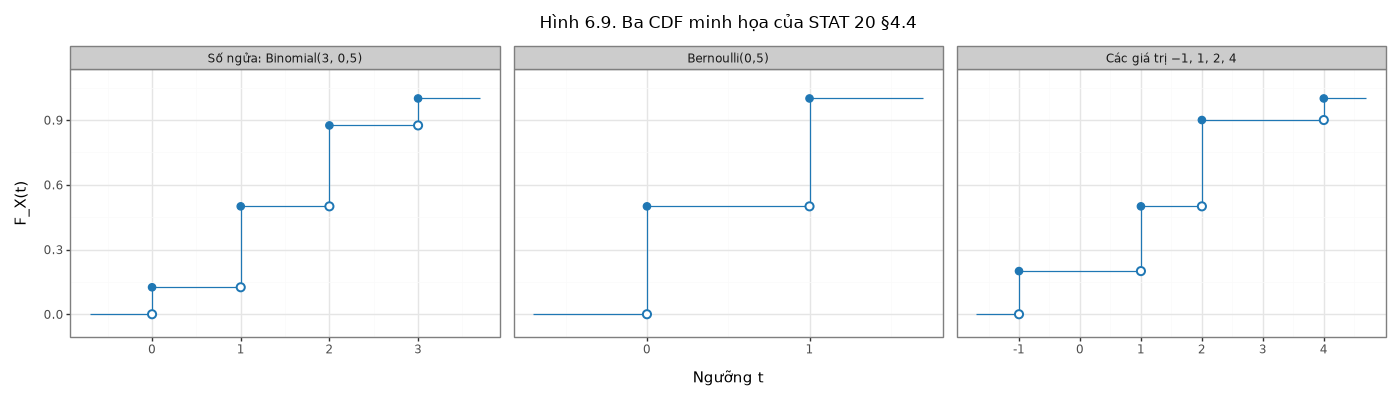

In [15]:
vi_du_cdf_stat20 = [
    (np.array([0, 1, 2, 3]), np.array([1, 3, 3, 1])/8, 'Số ngửa: Binomial(3, 0,5)'),
    (np.array([0, 1]), np.array([0.5, 0.5]), 'Bernoulli(0,5)'),
    (np.array([-1, 1, 2, 4]), np.array([0.2, 0.3, 0.4, 0.1]), 'Các giá trị −1, 1, 2, 4')]
duong_cdf_stat20 = []
diem_cdf_stat20 = []
for x_cdf, p_cdf, ten in vi_du_cdf_stat20:
    F_cdf = p_cdf.cumsum()
    duong_cdf_stat20.append(pd.DataFrame({'x': np.r_[x_cdf[0]-0.7, x_cdf, x_cdf[-1]+0.7],
                                          'F': np.r_[0, F_cdf, 1], 'Phan_phoi': ten}))
    diem_cdf_stat20.append(pd.DataFrame({'x': x_cdf, 'F': F_cdf,
                                         'F_trai': np.r_[0, F_cdf[:-1]], 'Phan_phoi': ten}))
    assert np.isclose(p_cdf.sum(), 1)
duong_cdf_stat20 = pd.concat(duong_cdf_stat20, ignore_index=True)
diem_cdf_stat20 = pd.concat(diem_cdf_stat20, ignore_index=True)
thu_tu_cdf = [ten for _, _, ten in vi_du_cdf_stat20]
for bang in [duong_cdf_stat20, diem_cdf_stat20]:
    bang['Phan_phoi'] = pd.Categorical(bang['Phan_phoi'], categories=thu_tu_cdf, ordered=True)
bieu_do = (p9.ggplot(duong_cdf_stat20, p9.aes('x', 'F'))
    + p9.geom_step(direction='hv', color='#1f77b4')
    + p9.geom_point(data=diem_cdf_stat20, color='#1f77b4', fill='#1f77b4', size=2.5)
    + p9.geom_point(data=diem_cdf_stat20, mapping=p9.aes(y='F_trai'),
                    shape='o', color='#1f77b4', fill='white', stroke=0.8, size=2.5)
    + p9.facet_wrap('Phan_phoi', nrow=1, scales='free_x')
    + p9.scale_x_continuous(breaks=[-1, 0, 1, 2, 3, 4])
    + p9.coord_cartesian(ylim=(-0.05, 1.08))
    + p9.labs(x='Ngưỡng t', y='F_X(t)',
              title='Hình 6.9. Ba CDF minh họa của STAT 20 §4.4')
    + p9.theme(figure_size=(14, 4)))
bieu_do.show()

Tại các điểm nhảy, ba CDF lần lượt bằng $(1/8;\ 1/2;\ 7/8;\ 1)$, $(1/2;\ 1)$ và $(0{,}2;\ 0{,}5;\ 0{,}9;\ 1)$. Giữa các điểm nhảy, CDF nằm ngang; trước điểm đầu nó bằng 0, từ điểm cuối trở đi nó bằng 1.

Ở hình bên phải, tại $t=2$ CDF bằng 0,9; độ nhảy tại đó là $0{,}9-0{,}5=0{,}4$. Tại $t=0$, CDF vẫn bằng 0,2, dù 0 không phải giá trị mà biến này có thể nhận. CDF được định nghĩa ở mọi số thực; PMF chỉ dương tại các giá trị có trong bảng.

<a id="hoc-1b157ebd"></a>
## 5. Các phân phối rời rạc thông dụng

Một **tham số** là con số xác định một phân phối trong một họ mô hình. Biết tên mô hình mà không biết tham số thì chưa tính được xác suất. Cùng là nhị thức, $(n,p)=(20;\ 0{,}25)$ và $(12;\ 0{,}95)$ mô tả hai thí nghiệm khác nhau.

### Ví dụ 9 — Phân phối đều rời rạc

Nếu $X$ nhận $m$ giá trị phân biệt với cùng xác suất, $X$ có **phân phối đều rời rạc**. Trên $\{1,\ldots,m\}$:

$$P(X=k)=\frac1m,\qquad k=1,\ldots,m.$$

$m$ là số giá trị có thể nhận. Các giá trị không cần liên tiếp; chỉ cần $m$ giá trị phân biệt, mỗi giá trị có xác suất $\frac1m$. Một biến cố gồm $r$ giá trị có xác suất $\frac rm$.

Xúc xắc cân đối có $m=6$, mỗi mặt có xác suất $\frac16$. Vậy $P(X\ge5)=P(X=5)+P(X=6)=\frac26=\frac13$.

**Bạn đoán trước:** nếu ghi tổng hai xúc xắc thay vì số chấm của một xúc xắc, phân phối còn đều không?

Trong code, `stats.randint.pmf(x_deu, low=1, high=7)` là PMF đều trên $1,\ldots,6$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

P(X≥5) = 0.3333333333333333


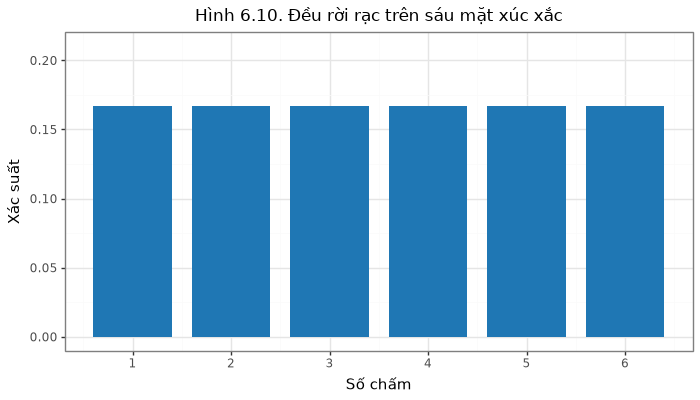

In [16]:
x_deu = np.arange(1, 7)
p_deu = stats.randint.pmf(x_deu, low=1, high=7)
print('P(X≥5) =', p_deu[x_deu >= 5].sum())

bang_deu = pd.DataFrame({'x': x_deu, 'p': p_deu})
bieu_do = (p9.ggplot(bang_deu, p9.aes('x', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.scale_x_continuous(breaks=x_deu)
    + p9.coord_cartesian(ylim=(0, 0.21))
    + p9.labs(x='Số chấm', y='Xác suất',
              title='Hình 6.10. Đều rời rạc trên sáu mặt xúc xắc'))
bieu_do.show()

Tổng hai xúc xắc không đều, vì mỗi tổng ứng với số cặp khác nhau (Ví dụ 2). Trong SciPy, `randint(low=1, high=7)` nhận các giá trị 1 đến 6: giống NumPy, cận trên không được lấy.

### Ví dụ 10 — Bernoulli và cách mã hóa 0/1

Một phép thử có hai loại kết quả. Gọi loại đang quan tâm là "thành công" và mã hóa bằng 1, loại còn lại bằng 0. Nếu xác suất thành công là $p$, ta viết

$$X\sim\operatorname{Bernoulli}(p),\qquad P(X=1)=p,\quad P(X=0)=1-p.$$

Đọc là: $X$ có phân phối Bernoulli với tham số $p\in[0,1]$. Có thể viết gọn thành một công thức: $p_X(x)=p^x(1-p)^{1-x}$ với $x\in\{0,1\}$; thay $x=1$ được $p$, thay $x=0$ được $1-p$.

"Thành công" chỉ là tên gọi. Nó có thể là một kết quả không mong muốn, như phát hiện linh kiện lỗi. Hãy chọn cách mã hóa trước khi xác định $p$.

Ví dụ 10 tung một đồng xu một lần: $X=1$ khi ngửa, $X=0$ khi sấp. Ba hình ứng với $p=\frac12,\frac34,\frac23$. Quan sát khối tại 0 thay đổi thế nào khi khối tại 1 tăng.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='p_X'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

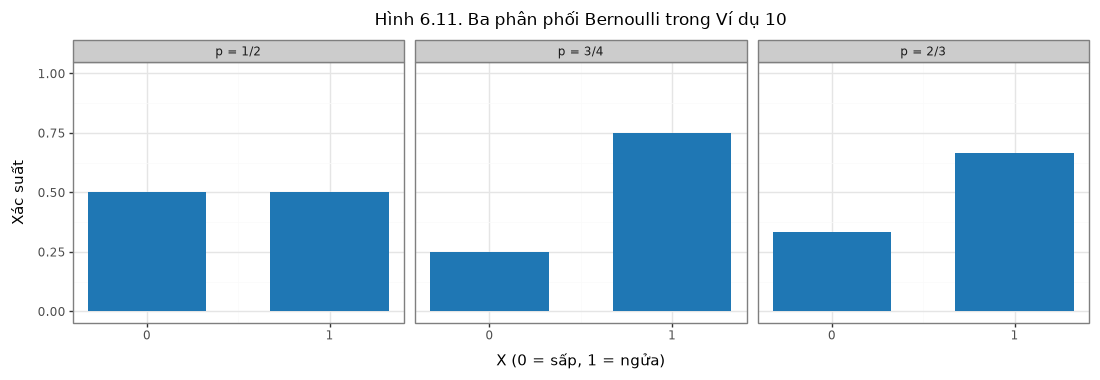

In [17]:
bang_bernoulli = []
for p, nhan in zip([1/2, 3/4, 2/3], ['1/2', '3/4', '2/3']):
    bang_bernoulli.append(pd.DataFrame({'x': [0, 1],
        'p_X': stats.bernoulli.pmf([0, 1], p=p), 'Tham_so': f'p = {nhan}'}))
bang_bernoulli = pd.concat(bang_bernoulli, ignore_index=True)
bang_bernoulli['Tham_so'] = pd.Categorical(bang_bernoulli['Tham_so'],
    categories=['p = 1/2', 'p = 3/4', 'p = 2/3'], ordered=True)
bieu_do = (p9.ggplot(bang_bernoulli, p9.aes('x', 'p_X'))
    + p9.geom_col(width=0.65, fill='#1f77b4')
    + p9.facet_wrap('Tham_so', nrow=1)
    + p9.scale_x_continuous(breaks=[0, 1])
    + p9.coord_cartesian(ylim=(0, 1))
    + p9.labs(x='X (0 = sấp, 1 = ngửa)', y='Xác suất',
              title='Hình 6.11. Ba phân phối Bernoulli trong Ví dụ 10')
    + p9.theme(figure_size=(11, 3.8)))
bieu_do.show()

Trong cả ba hình, hai chiều cao cộng lại bằng 1. Bernoulli không đòi hỏi $p=\frac12$. Nếu $p=0$ thì $X$ luôn bằng 0; nếu $p=1$ thì $X$ luôn bằng 1. Đó vẫn là những phân phối Bernoulli hợp lệ.

### Ví dụ 11 — Từ một số chọn đều tới một biến chỉ báo

Chọn ngẫu nhiên $N\in\{1,2,\ldots,1000\}$, mỗi số có cùng xác suất.

1. Tính xác suất $N$ chia hết cho 3, cho 5 và cho 15.
2. Đặt $Y=1$ nếu $N$ chia hết cho 3, $Y=0$ nếu không. Xác định phân phối của $Y$.

*Gợi ý.* Đếm số bội trong tập hữu hạn rồi mới chia cho 1.000. Không dùng $\frac13$ như giá trị chính xác, vì 1.000 không chia hết cho 3.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1: đếm bội.* Ký hiệu $\lfloor a\rfloor$ là phần nguyên của $a$.

- Bội của 3: $\lfloor1000/3\rfloor=333$ số.
- Bội của 5: $\lfloor1000/5\rfloor=200$ số.
- Bội của 15: $\lfloor1000/15\rfloor=66$ số.

1.000 số đồng khả năng, nên
$$P(N\text{ chia hết cho }3)=\frac{333}{1000}=0{,}333,\quad P(N\text{ chia hết cho }5)=0{,}200,\quad P(N\text{ chia hết cho }15)=0{,}066.$$

*Câu 2.* $Y$ chỉ nhận 0 và 1, với $P(Y=1)=0{,}333$ và $P(Y=0)=0{,}667$. Vậy $Y\sim\operatorname{Bernoulli}(0{,}333)$.

$N$ đều trên 1.000 giá trị; $Y$ thì không đều trên hai giá trị, vì 333 số được gán 1 còn 667 số được gán 0.

</details>

In [18]:
so_nguyen = np.arange(1, 1001)
for d in [3, 5, 15]:
    chia_het = so_nguyen % d == 0
    print(f'Chia hết cho {d:2d}: {chia_het.sum():3d} số, xác suất {chia_het.mean():.3f}')
Y_chia_3 = (so_nguyen % 3 == 0).astype(int)
print('PMF của Y:', {0: (Y_chia_3 == 0).mean(), 1: (Y_chia_3 == 1).mean()})

Chia hết cho  3: 333 số, xác suất 0.333
Chia hết cho  5: 200 số, xác suất 0.200
Chia hết cho 15:  66 số, xác suất 0.066
PMF của Y: {0: np.float64(0.667), 1: np.float64(0.333)}


Ô này duyệt toàn bộ 1.000 giá trị, nên kết quả là xác suất **chính xác**, không phải tần suất xấp xỉ. Cùng phép `.mean()` cho xác suất chính xác khi ta liệt kê toàn bộ các kết quả đồng khả năng, và cho tần suất khi ta chỉ mô phỏng một mẫu. Hãy luôn biết mình đang dùng loại dữ liệu nào.

### Phân phối nhị thức: đếm thành công trong $n$ lần thử

Lặp một phép thử Bernoulli $n$ lần rồi đếm số lần thành công. Ví dụ: kiểm tra 12 linh kiện trên một dây chuyền ổn định và đếm số linh kiện lỗi.

Mô hình **nhị thức** cần bốn điều kiện:

1. số phép thử $n$ cố định trước;
2. mỗi phép thử có hai loại kết quả (thành công hoặc thất bại);
3. các phép thử độc lập;
4. xác suất thành công $p$ như nhau ở mọi phép thử.

Khi đó số lần thành công $X$ có phân phối nhị thức, viết $X\sim\operatorname{Binomial}(n,p)$:

$$P(X=k)=\binom nk p^k(1-p)^{n-k},\qquad k=0,1,\ldots,n.$$

Đọc là: số cách chọn $k$ vị trí thành công trong $n$ lần thử, nhân với xác suất của một chuỗi có $k$ thành công và $n-k$ thất bại.

### Công thức đến từ đâu?

Công thức này không phải một định nghĩa mới. Nó suy ra từ quy tắc nhân (Tuần 05) và phép đếm (mục 2). Thử trước với $n=3$, $k=2$:

| Chuỗi có đúng 2 thành công | Xác suất (quy tắc nhân, vì độc lập) |
|---|---|
| SSF | $p\cdot p\cdot(1-p)=p^2(1-p)$ |
| SFS | $p\cdot(1-p)\cdot p=p^2(1-p)$ |
| FSS | $(1-p)\cdot p\cdot p=p^2(1-p)$ |

Ba chuỗi có cùng xác suất và xung khắc, nên $P(X=2)=3\,p^2(1-p)=\binom32p^2(1-p)^1$.

Tổng quát, làm theo bốn bước:

1. *Xác suất một chuỗi cụ thể.* Chuỗi có $k$ chữ S và $n-k$ chữ F có xác suất $p^k(1-p)^{n-k}$, theo quy tắc nhân cho các phép thử độc lập.
2. *Mọi chuỗi có cùng số chữ S đều có cùng xác suất.* Đổi chỗ các chữ chỉ đổi thứ tự các thừa số trong tích.
3. *Đếm số chuỗi.* Có $\binom nk$ chuỗi gồm đúng $k$ chữ S (mục 2).
4. *Cộng lại.* Các chuỗi khác nhau là các kết quả khác nhau, nên xung khắc; cộng $\binom nk$ xác suất bằng nhau.

Mỗi điều kiện của mô hình được dùng ở một bước. Thiếu điều kiện nào thì bước tương ứng sụp đổ, và không được dùng công thức nhị thức.

| Điều kiện | Cần cho bước |
|---|---|
| số phép thử $n$ cố định | có $n$ vị trí cố định để đếm (bước 3) |
| hai loại kết quả | chuỗi chỉ gồm S và F |
| các phép thử độc lập | được nhân các xác suất (bước 1) |
| $p$ không đổi | mọi thừa số đều là $p$ hoặc $1-p$ (bước 1 và 2) |

<details><summary><b>Vì sao?</b> Các xác suất nhị thức cộng lại bằng 1</summary>

Theo nhị thức Newton (mục 2) với $a=p$ và $b=1-p$:
$$\sum_{k=0}^n\binom nk p^k(1-p)^{n-k}=\big(p+(1-p)\big)^n=1^n=1.\ \blacksquare$$

Tên "nhị thức" đến từ chính đẳng thức này.

</details>

Hai trường hợp đặc biệt: $p=0$ thì $X$ luôn bằng 0; $p=1$ thì $X$ luôn bằng $n$. Nếu kết quả các linh kiện cùng phụ thuộc vào một lô nguyên liệu hỏng, điều kiện độc lập cần xét lại.

### Minh họa: ba lần tung một đồng xu lệch (Hình 6.12)

STAT 20 §3.4.3.3 tung ba lần độc lập một đồng xu lệch có $P(H)=\frac23$. Đây đúng là bốn bước trên với $n=3$, $p=\frac23$.

- Mỗi chuỗi có $k$ mặt ngửa có xác suất $\left(\frac23\right)^k\left(\frac13\right)^{3-k}$ (bước 1–2).
- Tám chuỗi không còn đồng khả năng, nhưng các chuỗi cùng số mặt ngửa thì có cùng xác suất.
- PMF của số mặt ngửa tại $0,1,2,3$ là $\frac1{27},\frac6{27},\frac{12}{27},\frac8{27}$.

Đúng hai mặt ngửa có xác suất lớn nhất: có $\binom32=3$ chuỗi, mỗi chuỗi có xác suất $\frac4{27}$.

Ô dưới in bảng tám chuỗi (dùng lại `bang_xu` của Ví dụ 3) kèm xác suất từng chuỗi, rồi vẽ PMF bằng `stats.binom.pmf`.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,Kết quả ω,X = số ngửa,Xác suất của chuỗi
0,HHH,3,0.296296
1,HHT,2,0.148148
2,HTH,2,0.148148
3,HTT,1,0.074074
4,THH,2,0.148148
5,THT,1,0.074074
6,TTH,1,0.074074
7,TTT,0,0.037037


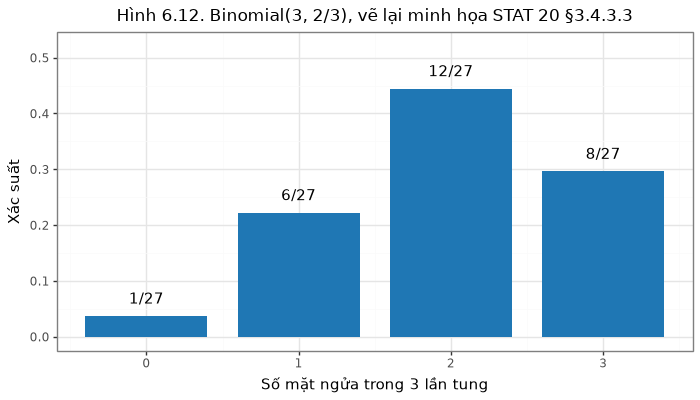

In [19]:
p_xu_lech = stats.binom.pmf(np.arange(4), n=3, p=2/3)
bang_xu_lech = bang_xu[['Kết quả ω', 'X = số ngửa']].copy()
bang_xu_lech['Xác suất của chuỗi'] = (2/3)**bang_xu_lech['X = số ngửa'] * (1/3)**(3-bang_xu_lech['X = số ngửa'])
display(bang_xu_lech)

bang_xu_lech_pmf = pd.DataFrame({'x': np.arange(4), 'p': p_xu_lech,
                                'nhan': ['1/27', '6/27', '12/27', '8/27']})
bieu_do = (p9.ggplot(bang_xu_lech_pmf, p9.aes('x', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.geom_text(p9.aes(label='nhan'), nudge_y=0.015, va='bottom')
    + p9.scale_x_continuous(breaks=range(4))
    + p9.coord_cartesian(ylim=(0, 0.52))
    + p9.labs(x='Số mặt ngửa trong 3 lần tung', y='Xác suất',
              title='Hình 6.12. Binomial(3, 2/3), vẽ lại minh họa STAT 20 §3.4.3.3'))
bieu_do.show()

### Ví dụ 12 — Làm ngẫu nhiên một bài trắc nghiệm

Bài có 20 câu, mỗi câu bốn phương án và chỉ một phương án đúng. Sinh viên chọn một phương án ngẫu nhiên cho mỗi câu, độc lập giữa các câu. Gọi $X$ là số câu đúng.

1. Xác định phân phối và tham số của $X$.
2. Tính xác suất đúng 8 câu.
3. Tính xác suất đúng **nhiều hơn 2** câu.

Giải thích từng điều kiện của nhị thức. Câu 3 có gồm trường hợp đúng 2 câu không?

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1: kiểm tra bốn điều kiện.*

- 20 câu: $n=20$ cố định.
- Mỗi câu chỉ đúng hoặc sai.
- Các câu được chọn độc lập (đề cho).
- Mỗi câu đúng với xác suất $\frac14=0{,}25$.

Vậy $X\sim\operatorname{Binomial}(20;\ 0{,}25)$.

*Câu 2.*
$$P(X=8)=\binom{20}{8}(0{,}25)^8(0{,}75)^{12}=125\,970\cdot(0{,}25)^8(0{,}75)^{12}\approx0{,}0609.$$

*Câu 3.* "Nhiều hơn 2" là $X\ge3$, **không** gồm 2. Có 18 giá trị từ 3 đến 20, nên dùng phần bù:
$$P(X>2)=1-P(X\le2)=1-\sum_{k=0}^{2}\binom{20}{k}(0{,}25)^k(0{,}75)^{20-k}.$$
Ba số hạng: $P(X=0)\approx0{,}0032$, $P(X=1)\approx0{,}0211$, $P(X=2)\approx0{,}0669$, tổng khoảng $0{,}0913$. Vậy $P(X>2)\approx0{,}9087$.

Theo mô hình đoán ngẫu nhiên, xác suất đúng 8 câu khoảng 6,09%; xác suất đúng ít nhất 3 câu khoảng 90,87%. Nếu sinh viên đã biết một số đáp án, xác suất đúng mỗi câu không còn là 0,25, và mô hình này không áp dụng.

</details>

In [20]:
p_dung_8_tay = comb(20, 8) * 0.25**8 * 0.75**12
p_hon_2_tay = 1 - sum(comb(20, k) * 0.25**k * 0.75**(20-k) for k in range(3))
print('P(X=8): tính công thức =', round(p_dung_8_tay, 4),
      '; SciPy =', round(stats.binom.pmf(8, n=20, p=0.25), 4))
print('P(X>2): tính phần bù =', round(p_hon_2_tay, 4),
      '; SciPy sf(2) =', round(stats.binom.sf(2, n=20, p=0.25), 4))
doan_bai = (rng.random((10000, 20)) < 0.25).sum(axis=1)
print('Mô phỏng P(X=8):', round((doan_bai == 8).mean(), 4))
print('Mô phỏng P(X>2):', round((doan_bai > 2).mean(), 4))
assert np.isclose(p_dung_8_tay, stats.binom.pmf(8, 20, 0.25))
assert np.isclose(p_hon_2_tay, stats.binom.sf(2, 20, 0.25))

P(X=8): tính công thức = 0.0609 ; SciPy = 0.0609
P(X>2): tính phần bù = 0.9087 ; SciPy sf(2) = 0.9087
Mô phỏng P(X=8): 0.0637
Mô phỏng P(X>2): 0.9089


Ô trên tính bằng công thức, bằng SciPy và bằng mô phỏng. Trong mô phỏng, mỗi hàng của `rng.random((10000, 20)) < 0.25` là một bài, mỗi cột một câu; tổng theo hàng là số câu đúng. Chênh lệch giữa tần suất và công thức là dao động mô phỏng.

### Hình 6.13. Đổi tham số $p$

Hình 6.13 giữ $n=20$ và cho đổi $p$. **Bạn đoán trước:** khi $p$ tăng, các giá trị $k$ có xác suất lớn sẽ dịch về phía nào? Chạy ô code để dùng thanh trượt ipywidgets; bảng dưới hình cho xác suất ở từng số câu đúng. Nếu trình xem chưa hỗ trợ widget, sửa `p_thanh_cong` rồi chạy lại ô. Ảnh ban đầu được lưu để đọc khi chưa kết nối kernel. Khi $p\ne0{,}25$, hình minh họa họ nhị thức nói chung, không còn là bài đoán bốn phương án.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='k', y='p_X'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Chạy ô để hiện hình ban đầu; widget cần kernel đang chạy. Đổi tham số của hàm vẽ và chạy lại nếu giao diện không hỗ trợ widget.

<!-- branch-plot-instructions:end -->

### Thử nghiệm bổ sung: đổi p trong khi giữ n = 20

Chọn `p = 0,10`, `0,25` rồi `0,50` bằng thanh trượt của hình bên dưới. Nếu chưa kết nối widget, sửa `p_thanh_cong` ở đầu ô rồi chạy lại.

Trước khi chạy, dự đoán vùng tập trung xác suất dịch theo chiều nào. Sau khi chạy, so vị trí đó với `np = 2; 5; 10`. Phương sai là `np(1-p)`, nên không tăng theo p trên toàn đoạn [0,1]. Tổng PMF vẫn bằng 1 dù hình dạng thay đổi.

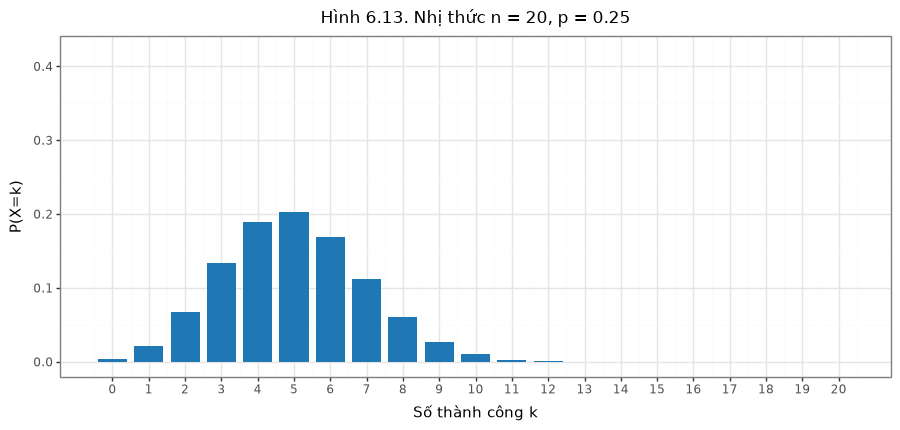

,k,P(X=k)
0,0,3.171212e-03
1,1,2.114141e-02
2,2,6.694781e-02
3,3,1.338956e-01
4,4,1.896855e-01
5,5,2.023312e-01
6,6,1.686093e-01
7,7,1.124062e-01
8,8,6.088669e-02
9,9,2.706075e-02


In [21]:
k_bin = np.arange(21)
p_grid = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
p_thanh_cong = 0.25  # Có thể sửa giá trị này rồi chạy lại ô để đổi p.

def ve_nhi_thuc(p):
    assert 0 <= p <= 1, 'p phải nằm trong khoảng từ 0 đến 1.'
    bang_nhi_thuc = pd.DataFrame({'k': k_bin, 'p_X': stats.binom.pmf(k_bin, n=20, p=p)})
    tran_y = max(0.42, 1.05 * bang_nhi_thuc['p_X'].max())
    return (p9.ggplot(bang_nhi_thuc, p9.aes('k', 'p_X'))
        + p9.geom_col(width=0.8, fill='#1f77b4')
        + p9.scale_x_continuous(breaks=k_bin)
        + p9.coord_cartesian(ylim=(0, tran_y))
        + p9.labs(x='Số thành công k', y='P(X=k)',
                  title=f'Hình 6.13. Nhị thức n = 20, p = {p:.2f}')
        + p9.theme(figure_size=(9, 4.3)))

def hien_thi_nhi_thuc(p):
    ve_nhi_thuc(p).show()
    display(pd.DataFrame({'k': k_bin, 'P(X=k)': stats.binom.pmf(k_bin, n=20, p=p)}))

# Ảnh ban đầu được lưu trong notebook để đọc cả khi chưa kết nối kernel.
hien_thi_nhi_thuc(p_thanh_cong)
try:
    import ipywidgets as widgets
    lua_chon_p = sorted(set(p_grid + [p_thanh_cong]))
    thanh_p = widgets.SelectionSlider(options=lua_chon_p, value=p_thanh_cong,
        description='p =', continuous_update=False)
    vung_do_thi = widgets.interactive_output(hien_thi_nhi_thuc, {'p': thanh_p})
    display(widgets.VBox([thanh_p, vung_do_thi]))
except ImportError:
    print('Để đổi p: sửa p_thanh_cong ở đầu ô rồi chạy lại; biểu đồ vẫn dùng Plotnine.')

Khi $p$ tăng, xác suất dồn về các giá trị $k$ lớn hơn. Với $p=0{,}5$ phân phối đối xứng; $p$ gần 0 hoặc gần 1 cho dạng lệch. Hình dạng không đủ để chọn mô hình: cơ chế thử phải đáp ứng bốn điều kiện nhị thức.

**Quay lại roulette.** Số lượt thắng $N$ trong sáu lượt độc lập có $N\sim\operatorname{Binomial}(6,\ 18/38)$. Vì $L=2N-6$, mỗi mức lãi $\ell$ ứng với đúng một số lượt thắng $N=\frac{\ell+6}2$. Chẳng hạn $L=2$ cần đúng bốn lượt thắng. Ô dưới đặt xác suất lý thuyết cạnh bảng mô phỏng ở mục 3.

In [22]:
p_lai_ly_thuyet = stats.binom.pmf(np.arange(7), n=6, p=18/38)
display(pd.DataFrame({'Lãi ròng (USD)': gia_tri_lai,
                      'Xác suất lý thuyết': p_lai_ly_thuyet,
                      'Tần suất đã mô phỏng': ts_lai}))
print('P(L=2) = P(N=4) =', round(stats.binom.pmf(4, n=6, p=18/38), 4))

,Lãi ròng (USD),Xác suất lý thuyết,Tần suất đã mô phỏng
0,-6,0.021256,0.0220
1,-4,0.114782,0.1182
2,-2,0.258259,0.2608
3,0,0.309910,0.3121
4,2,0.209189,0.2016
5,4,0.075308,0.0745
6,6,0.011296,0.0108


P(L=2) = P(N=4) = 0.2092


Bảng lý thuyết xác nhận: bảy mức lãi không có phân phối đều. Mô phỏng và công thức mô tả cùng một biến ngẫu nhiên, vì cùng dùng quy tắc lãi ròng $L=2N-6$.

### Ví dụ 13 — Sản phẩm đạt chuẩn

Dây chuyền có xác suất sản phẩm đạt chuẩn 0,95. Chọn độc lập 12 sản phẩm; $X$ là số sản phẩm đạt chuẩn.

1. Xác định phân phối của $X$.
2. Tính xác suất đúng 11 sản phẩm đạt.
3. Tính xác suất **ít nhất** 11 sản phẩm đạt.

Ở đây "thành công" là đạt chuẩn; ở bài đếm linh kiện lỗi, "thành công" có thể là lỗi. Chọn $p$ theo đúng đại lượng đang đếm.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* 12 sản phẩm chọn độc lập, mỗi sản phẩm đạt với xác suất 0,95, "thành công" là đạt chuẩn. Vậy $X\sim\operatorname{Binomial}(12;\ 0{,}95)$.

*Câu 2.*
$$P(X=11)=\binom{12}{11}(0{,}95)^{11}(0{,}05)=12\cdot(0{,}95)^{11}\cdot0{,}05\approx0{,}3413.$$

*Câu 3.* "Ít nhất 11" gồm 11 **và** 12:
$$P(X\ge11)=P(X=11)+P(X=12)=0{,}34128+(0{,}95)^{12}\approx0{,}34128+0{,}54036=0{,}88164.$$

Đúng 11 có xác suất khoảng 34,13%; ít nhất 11 có xác suất khoảng 88,16%, vì gồm cả trường hợp 12. Làm tròn ba chữ số: 0,341 và 0,882.

</details>

In [23]:
print('Đúng 11 đạt:', round(stats.binom.pmf(11, n=12, p=0.95), 4))
print('Ít nhất 11 đạt:', round(stats.binom.sf(10, n=12, p=0.95), 4))
print('Cả 12 đạt:', round(stats.binom.pmf(12, n=12, p=0.95), 4))

Đúng 11 đạt: 0.3413
Ít nhất 11 đạt: 0.8816
Cả 12 đạt: 0.5404


`sf(10)` tính $P(X>10)$, tức $P(X\ge11)$ khi $X$ nguyên. Gọi `sf(11)` thì chỉ được $P(X>11)=P(X=12)$, bỏ mất trường hợp đúng 11.

### Phân phối siêu bội: rút không hoàn lại từ một hộp hữu hạn

Hộp có $N$ lá thăm phân biệt: $K$ lá ghi 1 và $N-K$ lá ghi 0. Rút ngẫu nhiên $n$ lá **không hoàn lại**; mọi nhóm $n$ lá có cùng khả năng. Gọi $X$ là số lá ghi 1 trong mẫu. Ta viết

$$X\sim\operatorname{Hypergeometric}(N,K,n).$$

$N$ là tổng số lá, $K$ là số lá "thành công" trong hộp, $n$ là cỡ mẫu. Các lần rút phụ thuộc nhau: lấy ra một lá 1 làm đổi thành phần hộp cho lần sau. Đó là chỗ khác với nhị thức.

**Suy ra công thức bằng đếm.**

1. Không quan tâm thứ tự, mỗi kết quả là một **nhóm** $n$ lá. Có $\binom Nn$ nhóm, đồng khả năng.
2. Nhóm thuận lợi gồm $k$ lá lấy từ $K$ lá ghi 1 **và** $n-k$ lá lấy từ $N-K$ lá ghi 0. Theo quy tắc nhân có $\binom Kk\binom{N-K}{n-k}$ nhóm như vậy.
3. Chia số nhóm thuận lợi cho tổng số nhóm (công thức đếm của Tuần 05):

$$P(X=k)=\frac{\binom Kk\binom{N-K}{n-k}}{\binom Nn}.$$

Đọc là: số cách chọn $k$ lá 1 nhân với số cách chọn $n-k$ lá 0, chia cho số cách chọn $n$ lá bất kỳ.

Chỉ dùng các $k$ nguyên thỏa

$$\max(0,\ n-(N-K))\le k\le\min(n,\ K).$$

Cận dưới bảo đảm không cần nhiều lá 0 hơn số lá 0 hộp có; cận trên bảo đảm không cần nhiều lá 1 hơn số lá 1 hộp có. Ngoài khoảng này, xác suất bằng 0.

<details><summary><b>Đọc thêm</b> Vì sao các xác suất siêu bội cộng lại bằng 1</summary>

Cần chứng minh $\sum_k\binom Kk\binom{N-K}{n-k}=\binom Nn$. Vế phải đếm mọi nhóm $n$ lá. Vế trái đếm cùng các nhóm đó, nhưng chia theo số lá ghi 1 trong nhóm. Đẳng thức này có tên là đẳng thức Vandermonde.

</details>

### Ví dụ 14 — Ba lá từ hộp mười lá

Hộp có 6 lá ghi 1 và 4 lá ghi 0. Rút lần lượt ba lá không hoàn lại, mỗi lần chọn đều trong các lá còn lại. $X$ là số lá 1 trong mẫu. Tính $P(X=2)$.

*Gợi ý.* Trước tiên xác định $N$, $K$, $n$. Đúng hai lá 1 nghĩa là chọn hai lá trong sáu lá 1 và một lá trong bốn lá 0; thứ tự rút không ảnh hưởng tới số lá 1.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1: tham số.* $N=10$ lá, $K=6$ lá ghi 1, $n=3$. Vậy $X\sim\operatorname{Hypergeometric}(10,6,3)$.

*Bước 2: đếm.* Có $\binom{10}3=120$ nhóm 3 lá. Nhóm có đúng hai lá 1: chọn 2 trong 6 lá 1 ($\binom62=15$ cách) và 1 trong 4 lá 0 ($\binom41=4$ cách), tức $15\cdot4=60$ nhóm.

*Bước 3.*
$$P(X=2)=\frac{\binom62\binom41}{\binom{10}3}=\frac{60}{120}=0{,}5.$$

Toàn bộ PMF, tính cùng cách:

| $k$ | 0 | 1 | 2 | 3 |
|---|---:|---:|---:|---:|
| Số nhóm | $1\cdot4=4$ | $6\cdot6=36$ | $15\cdot4=60$ | $20\cdot1=20$ |
| $P(X=k)$ | $1/30$ | $3/10$ | $1/2$ | $1/6$ |

Tổng số nhóm là $4+36+60+20=120$, nên các xác suất cộng lại bằng 1. Đúng hai lá 1 có xác suất lớn nhất trong bốn khả năng. Không được nhân ba xác suất cố định 0,6: khi rút không hoàn lại, xác suất của lần sau tùy vào kết quả đã lấy.

</details>

**Code.** Ô dưới kiểm tra bằng SciPy và bằng mô phỏng. Chú ý tên tham số của `stats.hypergeom`: `M` là kích thước hộp ($N$), `n` là số lá 1 ($K$), `N` là cỡ mẫu ($n$). Chữ hoa, chữ thường của SciPy khác ký hiệu trong bài, nên luôn gọi bằng tên đối số để tránh đảo số.

Phần mô phỏng lặp 5.000 lần. Mỗi lần, `rng.choice(hop01, size=3, replace=False)` rút ba lá không hoàn lại từ hộp đầy đủ, rồi `.sum()` đếm số lá 1.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `y='tan_suat'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

Tần suất X=2: 0.5038
Xác suất X=2: 0.5000000000000001


,k,PMF tính tay,SciPy,Tần suất
0,0,0.033333,0.033333,0.0292
1,1,0.300000,0.300000,0.2976
2,2,0.500000,0.500000,0.5038
3,3,0.166667,0.166667,0.1694


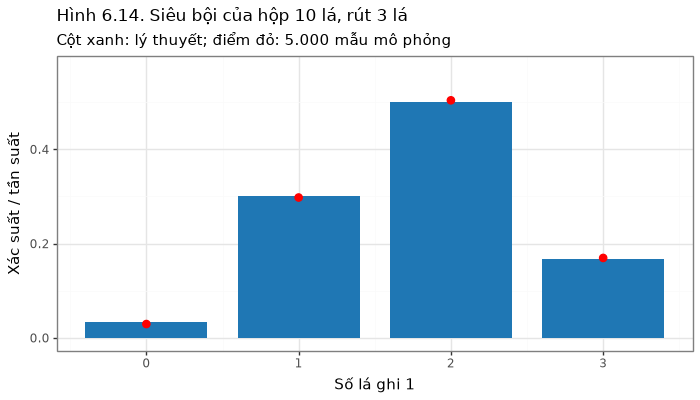

In [24]:
x_hg = np.arange(4)
p_hg = stats.hypergeom.pmf(x_hg, M=10, n=6, N=3)
p_hg_tay = np.array([comb(6, k) * comb(4, 3-k) / comb(10, 3) for k in x_hg])
assert np.allclose(p_hg, p_hg_tay)
hop01 = np.array([1]*6 + [0]*4)
ket_qua_hg = []
for i in range(5000):
    lan_rut = rng.choice(hop01, size=3, replace=False)
    ket_qua_hg.append(lan_rut.sum())
ket_qua_hg = np.array(ket_qua_hg)
ts_hg = np.array([(ket_qua_hg == k).mean() for k in x_hg])
print('Tần suất X=2:', round((ket_qua_hg == 2).mean(), 4))
print('Xác suất X=2:', stats.hypergeom.pmf(2, M=10, n=6, N=3))
display(pd.DataFrame({'k': x_hg, 'PMF tính tay': p_hg_tay, 'SciPy': p_hg, 'Tần suất': ts_hg}))

bang_hg = pd.DataFrame({'k': x_hg, 'p': p_hg, 'tan_suat': ts_hg})
bieu_do = (p9.ggplot(bang_hg, p9.aes('k', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.geom_point(p9.aes(y='tan_suat'), color='red', size=2.5)
    + p9.scale_x_continuous(breaks=x_hg)
    + p9.coord_cartesian(ylim=(0, 0.57))
    + p9.labs(x='Số lá ghi 1', y='Xác suất / tần suất',
              title='Hình 6.14. Siêu bội của hộp 10 lá, rút 3 lá',
              subtitle='Cột xanh: lý thuyết; điểm đỏ: 5.000 mẫu mô phỏng'))
bieu_do.show()

`replace=False` chỉ áp dụng **trong mỗi bộ ba lá**. Lần lặp sau bắt đầu lại với đủ 10 lá; các lá đã rút ở lần lặp trước được trả về hộp. Tần suất của $X=2$ dao động quanh 0,5.

### Ví dụ 15 — Mười lăm bài dự án đầu tiên

Giảng viên dạy hai lớp, gồm 20 và 30 sinh viên. Mỗi sinh viên nộp một bài dự án. Xáo ngẫu nhiên 50 bài rồi chấm 15 bài đầu; mọi thứ tự có cùng khả năng. Gọi $X$ là số bài của **lớp thứ hai** trong 15 bài đầu.

1. Tính xác suất có đúng 10 bài lớp thứ hai.
2. Tính xác suất ít nhất 10 trong 15 bài thuộc **cùng một lớp**.

*Gợi ý.* Câu 2 không chỉ hỏi về lớp thứ hai. Viết hai khả năng: lớp thứ hai có ít nhất 10 bài, hoặc lớp thứ nhất có ít nhất 10 bài.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1: mô hình.* Xáo ngẫu nhiên 50 bài rồi lấy 15 bài đầu là rút một mẫu 15 bài không hoàn lại. "Thành công" là bài của lớp thứ hai: $N=50$, $K=30$, $n=15$. Vậy $X\sim\operatorname{Hypergeometric}(50,30,15)$.

*Câu 1.*
$$P(X=10)=\frac{\binom{30}{10}\binom{20}{5}}{\binom{50}{15}}\approx0{,}2070.$$

*Câu 2.* Lớp thứ nhất có $15-X$ bài. "Ít nhất 10 bài cùng một lớp" nghĩa là $X\ge10$ **hoặc** $15-X\ge10$, tức $X\ge10$ hoặc $X\le5$. Hai miền xung khắc, nên cộng:
$$P(X\ge10)+P(X\le5)=\sum_{k=10}^{15}p_X(k)+\sum_{k=0}^{5}p_X(k)\approx0{,}3798+0{,}0140=0{,}3938.$$

Xáo ngẫu nhiên tạo một mẫu không hoàn lại, không tạo 15 lượt độc lập. Xác suất 0,3938 tính cho cả hai lớp, không phải xác suất lớp thứ hai có ít nhất 10 bài.

</details>

In [25]:
rv_bai = stats.hypergeom(M=50, n=30, N=15)
print('Đúng 10 bài lớp thứ hai:', round(rv_bai.pmf(10), 4))
print('Ít nhất 10 bài cùng một lớp:', round(rv_bai.sf(9) + rv_bai.cdf(5), 4))
print('Hai phần xung khắc:', round(rv_bai.sf(9), 4), 'và', round(rv_bai.cdf(5), 4))

Đúng 10 bài lớp thứ hai: 0.207
Ít nhất 10 bài cùng một lớp: 0.3938
Hai phần xung khắc: 0.3798 và 0.014


`sf(9)` lấy $X\ge10$; `cdf(5)` lấy $X\le5$. Được cộng hai số này vì không có giá trị $X$ nào vừa ít nhất 10 vừa không quá 5.

### Ví dụ 16 — Có và không hoàn lại từ hộp bốn bóng

Hộp có hai bóng đỏ và hai bóng xanh. Rút ngẫu nhiên ba lần; mỗi lần, mọi bóng còn trong hộp cùng khả năng được lấy. So sánh **có hoàn lại** và **không hoàn lại**. $X$ là số bóng đỏ được rút.

1. Xác định các giá trị của $X$ và lập phân phối trong từng cách rút.
2. Tính $P(X=3)$ và $P(X=2)$ cho từng cách.
3. Giải thích vì sao hai phân phối khác nhau.

*Gợi ý.* Hộp chỉ có hai bóng đỏ. Đặt bóng trở lại thì có thể rút được ba lượt đỏ; không đặt lại thì không có đủ ba bóng đỏ.

<details><summary>Đáp án và cách lập luận</summary>

*Có hoàn lại.* Mỗi lần rút, hộp vẫn có 2 đỏ, 2 xanh; các lần độc lập và xác suất đỏ luôn là $\frac12$. Vậy $X\sim\operatorname{Binomial}(3,\ 1/2)$, nhận $0,1,2,3$.

*Không hoàn lại.* $X\sim\operatorname{Hypergeometric}(4,2,3)$. Lấy ba trong bốn bóng mà mỗi màu chỉ có hai, nên mẫu luôn có cả hai màu: $X$ chỉ nhận 1 hoặc 2. Có $\binom43=4$ nhóm; nhóm có 1 đỏ: $\binom21\binom22=2$; nhóm có 2 đỏ: $\binom22\binom21=2$.

| $x$ | 0 | 1 | 2 | 3 |
|---|---:|---:|---:|---:|
| Có hoàn lại | $1/8$ | $3/8$ | $3/8$ | $1/8$ |
| Không hoàn lại | 0 | $1/2$ | $1/2$ | 0 |

*Câu 2.* $P(X=3)$ lần lượt là $\frac18$ và 0; $P(X=2)$ lần lượt là $\frac38$ và $\frac12$.

*Câu 3.* Khi không hoàn lại, sau lần đầu ra đỏ, xác suất ra đỏ ở lần sau là $\frac13$; sau lần đầu ra xanh, xác suất đó là $\frac23$. Thành phần hộp thay đổi làm các lần rút phụ thuộc nhau.

</details>

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='k', y='p', fill='Cach_rut'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,x,Có hoàn lại,Không hoàn lại
0,0,0.125,0.0
1,1,0.375,0.5
2,2,0.375,0.5
3,3,0.125,0.0


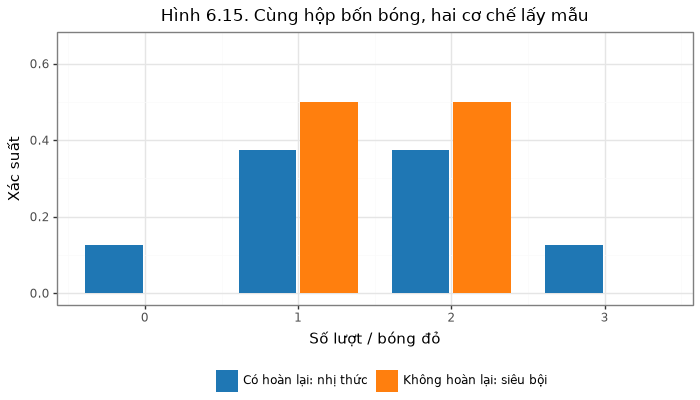

In [26]:
k_bong = np.arange(4)
p_bong_co = stats.binom.pmf(k_bong, n=3, p=0.5)
p_bong_khong = stats.hypergeom.pmf(k_bong, M=4, n=2, N=3)
display(pd.DataFrame({'x': k_bong, 'Có hoàn lại': p_bong_co, 'Không hoàn lại': p_bong_khong}))

bang_bong = pd.concat([
    pd.DataFrame({'k': k_bong, 'p': p_bong_co, 'Cach_rut': 'Có hoàn lại: nhị thức'}),
    pd.DataFrame({'k': k_bong, 'p': p_bong_khong, 'Cach_rut': 'Không hoàn lại: siêu bội'})],
    ignore_index=True)
bieu_do = (p9.ggplot(bang_bong, p9.aes('k', 'p', fill='Cach_rut'))
    + p9.geom_col(width=0.75, position=p9.position_dodge(width=0.8))
    + p9.scale_fill_manual(values={'Có hoàn lại: nhị thức': '#1f77b4',
                                    'Không hoàn lại: siêu bội': '#ff7f0e'})
    + p9.scale_x_continuous(breaks=k_bong)
    + p9.coord_cartesian(ylim=(0, 0.65))
    + p9.labs(x='Số lượt / bóng đỏ', y='Xác suất', fill='',
              title='Hình 6.15. Cùng hộp bốn bóng, hai cơ chế lấy mẫu'))
bieu_do.show()

### Khi nào siêu bội gần với nhị thức?

Nhị thức và siêu bội đều đếm số thành công trong một số lần rút cố định; chúng khác nhau ở cơ chế lấy mẫu. Nếu hộp rất lớn so với cỡ mẫu, lấy ra vài lá gần như không đổi thành phần hộp. Các lần rút khi đó "gần như độc lập", và

$$\operatorname{Hypergeometric}(N,K,n)\approx\operatorname{Binomial}(n,p)\quad\text{với }p=K/N.$$

*Ví dụ.* Với $n=10$ và tỉ lệ thành công $0{,}3$, so sánh $P(X=3)$:

| Mô hình | $P(X=3)$ |
|---|---:|
| Nhị thức $(10;\ 0{,}3)$ | 0,2668 |
| Siêu bội, $N=1000$, $K=300$ | 0,2682 |
| Siêu bội, $N=20$, $K=6$ | 0,3715 |

Với $N=1000$, hai mô hình gần như trùng nhau. Với $N=20$, rút 10 lá là lấy đi một nửa hộp, và hai mô hình khác nhau rõ. Vì vậy một cuộc khảo sát chọn 1.000 người trong hàng triệu người thường được tính như lấy mẫu có hoàn lại, dù thực tế không ai bị hỏi hai lần.

<details><summary><b>Vì sao?</b> Tích các xác suất gần bằng $p^k$</summary>

Xác suất để $k$ lần rút đầu đều ra lá ghi 1 là
$$\frac KN\cdot\frac{K-1}{N-1}\cdots\frac{K-k+1}{N-k+1}.$$
Khi $N$ và $K$ rất lớn so với $k$, mỗi phân số gần bằng $\frac KN=p$, nên tích gần bằng $p^k$, như ở mô hình nhị thức. Xấp xỉ này không biến rút không hoàn lại thành độc lập chính xác.

</details>

**Code.** Ô dưới làm phép so sánh theo STAT 20 §4.3.2.6: giữ $n=10$ và tỉ lệ $K/N=\frac12$, cho hộp có 20, 100 và 1.000 lá. Quan sát xác suất không có thành công và độ lệch lớn nhất giữa hai PMF. Ví dụ của nguồn dùng $N=1000$, $K=500$, $n=10$: xác suất không có thành công khoảng 0,0009 theo siêu bội và $0{,}5^{10}\approx0{,}000977$ theo nhị thức.

In [27]:
k_so_sanh = np.arange(11)
p_bin_10 = stats.binom.pmf(k_so_sanh, n=10, p=0.5)
so_sanh_xap_xi = []
for N_hop in [20, 100, 1000]:
    p_sieu_boi = stats.hypergeom.pmf(k_so_sanh, M=N_hop, n=N_hop//2, N=10)
    so_sanh_xap_xi.append({'N': N_hop, 'n/N': 10/N_hop,
        'P_HG(X=0)': p_sieu_boi[0], 'P_Bin(X=0)': p_bin_10[0],
        'Sai khác PMF lớn nhất': np.max(np.abs(p_sieu_boi-p_bin_10))})
display(pd.DataFrame(so_sanh_xap_xi))

,N,n/N,P_HG(X=0),P_Bin(X=0),Sai khác PMF lớn nhất
0,20,0.50,0.000005,0.000977,0.097624
1,100,0.10,0.000593,0.000977,0.013240
2,1000,0.01,0.000933,0.000977,0.001239


Với cùng cỡ mẫu và cùng tỉ lệ thành công, hộp càng lớn thì hai PMF càng gần nhau. Khi dùng xấp xỉ, câu hỏi cần trả lời là: mức sai lệch có chấp nhận được với bài toán đang giải không? Tên "nhị thức" không thay được việc mô tả cơ chế chọn mẫu.

<a id="hoc-7e8bbdfe"></a>
## 6. Phân phối Poisson: đếm sự kiện trong một khoảng

Số yêu cầu đến máy chủ trong một giây không có một số phép thử $n$ cố định như bài trắc nghiệm. **Phân phối Poisson** mô tả số sự kiện trong một khoảng quan sát, với tham số $\lambda>0$ (đọc là *lam-đa*):

$$X\sim\operatorname{Poisson}(\lambda),\qquad P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},\quad k=0,1,2,\ldots$$

- $k$ là số sự kiện; $k!$ là giai thừa; $e\approx2{,}71828$.
- $\lambda$ là số sự kiện trung bình **trong cả khoảng đang đếm**.
- $X$ nhận mọi số nguyên không âm; không có cận trên.

Mô hình hợp lý khi: tốc độ trung bình ổn định; số sự kiện ở các khoảng không giao nhau độc lập; trong một khoảng rất ngắn, hầu như không có hai sự kiện cùng lúc. Có những hệ thống không phù hợp: yêu cầu đến thành đợt sau một thông báo lớn, hay tốc độ thay đổi nhiều giữa giờ cao điểm và thấp điểm.

Nếu tốc độ là $r$ sự kiện mỗi giây và quan sát trong $t$ giây, tham số là $\lambda=rt$. Đơn vị thời gian phải khớp với đơn vị tốc độ: không thay $\lambda=4$ vào bài đếm ba giây chỉ vì tốc độ là 4 mỗi giây.

<details><summary><b>Vì sao?</b> Các xác suất Poisson cộng lại bằng 1</summary>

Từ Giải tích 1, hàm mũ có khai triển
$$e^{\lambda}=\sum_{k=0}^\infty\frac{\lambda^k}{k!}=1+\lambda+\frac{\lambda^2}{2!}+\cdots$$
Do đó
$$\sum_{k=0}^\infty e^{-\lambda}\frac{\lambda^k}{k!}=e^{-\lambda}\cdot e^{\lambda}=1.\ \blacksquare$$

</details>

**Công thức đến từ đâu?** Chia khoảng quan sát thành $n$ khoảng rất nhỏ. Giả sử mỗi khoảng nhỏ có nhiều nhất một sự kiện, xảy ra với cùng xác suất $p=\lambda/n$, và các khoảng độc lập. Khi đó số sự kiện có phân phối $\operatorname{Binomial}(n,\lambda/n)$. Cho $n$ tăng mãi, xác suất nhị thức tiến tới xác suất Poisson. Cuối mục này có bảng so sánh bằng số và chứng minh.

### Ví dụ 17 — Poisson với tham số 1

$X$ là số sự kiện trong một khoảng cố định, $X\sim\operatorname{Poisson}(1)$. Tính xác suất sự kiện xảy ra **đúng một lần** và **không quá một lần**.

*Gợi ý.* "Đúng một lần" là một khối của PMF; "không quá một lần" gồm 0 và 1.

<details><summary>Đáp án và cách lập luận</summary>

*Đúng một lần.*
$$P(X=1)=\frac{e^{-1}1^1}{1!}=e^{-1}\approx0{,}3679.$$

*Không quá một lần* gồm 0 và 1. Vì $P(X=0)=\dfrac{e^{-1}1^0}{0!}=e^{-1}$ (nhớ $0!=1$ và $1^0=1$),
$$P(X\le1)=P(X=0)+P(X=1)=2e^{-1}\approx0{,}7358.$$

Vậy một khoảng có đúng một sự kiện với xác suất khoảng 36,79%, và không quá một sự kiện với xác suất khoảng 73,58%. "Không quá một" vẫn gồm trường hợp không có sự kiện nào.

</details>

Ô dưới kiểm tra bằng SciPy: `stats.poisson.pmf(1, mu=1)` và `stats.poisson.cdf(1, mu=1)`. Tham số `mu` của SciPy chính là $\lambda$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='k', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

P(X=1): 0.3679
P(X≤1): 0.7358
Khối xác suất còn ngoài hình, P(X>8): 1.1252025979690174e-06


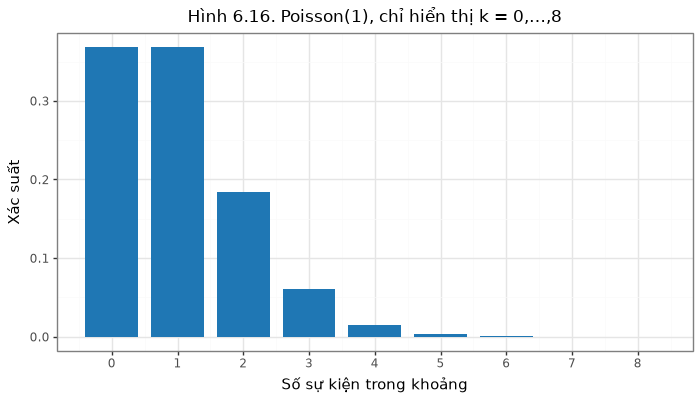

In [28]:
k_pois = np.arange(9)
p_pois = stats.poisson.pmf(k_pois, mu=1)
print('P(X=1):', round(stats.poisson.pmf(1, mu=1), 4))
print('P(X≤1):', round(stats.poisson.cdf(1, mu=1), 4))
print('Khối xác suất còn ngoài hình, P(X>8):', stats.poisson.sf(8, mu=1))

bang_poisson = pd.DataFrame({'k': k_pois, 'p': p_pois})
bieu_do = (p9.ggplot(bang_poisson, p9.aes('k', 'p'))
    + p9.geom_col(width=0.8, fill='#1f77b4')
    + p9.scale_x_continuous(breaks=k_pois)
    + p9.labs(x='Số sự kiện trong khoảng', y='Xác suất',
              title='Hình 6.16. Poisson(1), chỉ hiển thị k = 0,…,8'))
bieu_do.show()
assert np.isclose(p_pois[0], p_pois[1])

Hai cột 0 và 1 có cùng chiều cao $e^{-1}$. Hình chỉ vẽ từ 0 tới 8 cho dễ nhìn; không có nghĩa là $X$ không thể vượt 8. Tổng các cột hiển thị nhỏ hơn 1 đúng bằng xác suất đuôi mà ô trên in ra. Đừng chuẩn hóa lại các cột để biến phần hiển thị thành cả phân phối.

### Ví dụ 18 — Máy chủ nhận yêu cầu

Máy chủ nhận trung bình 4 yêu cầu/giây. Giả sử yêu cầu đến theo mô hình Poisson với tốc độ ổn định; số yêu cầu trong các khoảng không giao nhau độc lập. Đặt $X$ là số yêu cầu trong một giây.

1. Tính xác suất không có yêu cầu.
2. Tính xác suất có nhiều hơn 6 yêu cầu.
3. Xác định phân phối số yêu cầu trong 3 giây.

*Gợi ý.* Trước khi tính, ghi đơn vị của tốc độ và độ dài khoảng. Câu 3 đếm trong ba giây, không phải một giây.

<details><summary>Đáp án và cách lập luận</summary>

$X\sim\operatorname{Poisson}(4)$: trung bình 4 yêu cầu trong khoảng một giây đang đếm.

*Câu 1.* $P(X=0)=\dfrac{e^{-4}4^0}{0!}=e^{-4}\approx0{,}0183$.

*Câu 2.* "Nhiều hơn 6" là phần bù của "không quá 6":
$$P(X>6)=1-\sum_{k=0}^{6}\frac{e^{-4}4^k}{k!}\approx0{,}1107.$$

*Câu 3.* Trong ba giây, $\lambda=3\cdot4=12$, nên số yêu cầu có phân phối $\operatorname{Poisson}(12)$. Xác suất 0,1107 ở câu 2 tính cho **một giây**; nó không dùng nguyên được cho khoảng ba giây.

</details>

**Vì sao ba giây cho Poisson(12)?** Ba giây là ba khoảng một giây rời nhau. Theo mô hình, số yêu cầu trong mỗi khoảng có phân phối $\operatorname{Poisson}(4)$, và ba khoảng độc lập. Tính chất sau cho kết quả.

**Cộng hai biến Poisson độc lập.** Nếu $X\sim\operatorname{Poisson}(\lambda)$ và $Y\sim\operatorname{Poisson}(\mu)$ độc lập thì

$$X+Y\sim\operatorname{Poisson}(\lambda+\mu).$$

Đọc là: tổng hai số đếm Poisson độc lập vẫn là Poisson, với tham số bằng tổng hai tham số. Áp dụng hai lần cho ba khoảng một giây: $4+4+4=12$.

<details><summary><b>Vì sao?</b> Tổng hai biến Poisson độc lập là Poisson</summary>

*Bước 1.* Để $X+Y=m$, cần $X=k$ và $Y=m-k$ với một $k$ nào đó từ 0 đến $m$. Các trường hợp ứng với $k$ khác nhau thì xung khắc.

*Bước 2.* $X$, $Y$ độc lập nên nhân được:
$$P(X+Y=m)=\sum_{k=0}^m e^{-\lambda}\frac{\lambda^k}{k!}\cdot e^{-\mu}\frac{\mu^{m-k}}{(m-k)!}.$$

*Bước 3.* Đưa $e^{-(\lambda+\mu)}$ ra ngoài, nhân và chia cho $m!$, rồi nhận ra $\frac{m!}{k!\,(m-k)!}=\binom mk$:
$$P(X+Y=m)=\frac{e^{-(\lambda+\mu)}}{m!}\sum_{k=0}^m\binom mk\lambda^k\mu^{m-k}.$$

*Bước 4.* Theo nhị thức Newton, tổng bằng $(\lambda+\mu)^m$. Vậy
$$P(X+Y=m)=e^{-(\lambda+\mu)}\frac{(\lambda+\mu)^m}{m!}.\ \blacksquare$$

</details>

**Code.** Ô dưới tính câu 1–2 bằng SciPy (`sf(6)` là $P(X>6)$), rồi tính $\lambda$ cho một khoảng dài `thoi_gian` giây.

In [29]:
print('Không có yêu cầu trong 1 giây:', round(stats.poisson.pmf(0, mu=4), 4))
print('Hơn 6 yêu cầu trong 1 giây:', round(stats.poisson.sf(6, mu=4), 4))
toc_do = 4  # yêu cầu / giây
thoi_gian = 3  # giây; thử đổi thành 1 hoặc 5
lam = toc_do * thoi_gian
print(f'Khoảng {thoi_gian} giây: Poisson({lam}), P(0 yêu cầu) = {stats.poisson.pmf(0, mu=lam):.6f}')

Không có yêu cầu trong 1 giây: 0.0183
Hơn 6 yêu cầu trong 1 giây: 0.1107
Khoảng 3 giây: Poisson(12), P(0 yêu cầu) = 0.000006


Đổi `thoi_gian` thì $\lambda$ đổi theo độ dài khoảng. Chỉ biết tốc độ trung bình thì chưa đủ để kết luận phân phối là Poisson; giả định ổn định và độc lập giữa các khoảng vẫn phải đáp ứng.

### Poisson là giới hạn của nhị thức

Nếu có rất nhiều phép thử Bernoulli độc lập, mỗi phép thử có xác suất thành công nhỏ, thì $\operatorname{Binomial}(n,p)$ gần $\operatorname{Poisson}(\lambda)$ với $\lambda=np$. Ví dụ so sánh $\operatorname{Binomial}(1000;\ 0{,}003)$ với $\operatorname{Poisson}(3)$:

| $k$ | 0 | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|---:|
| Nhị thức | 0,0496 | 0,1491 | 0,2242 | 0,2244 | 0,1683 |
| Poisson(3) | 0,0498 | 0,1494 | 0,2240 | 0,2240 | 0,1680 |

Vì vậy Poisson là mô hình tự nhiên cho **số lần xảy ra của một sự kiện hiếm trong rất nhiều cơ hội độc lập**: số cuộc gọi trong một phút, số lỗi trên một trang in.

<details><summary><b>Vì sao?</b> Xác suất nhị thức tiến tới xác suất Poisson</summary>

Đặt $p=\lambda/n$ và giữ $k$ cố định. Viết xác suất nhị thức thành tích bốn thừa số:
$$\binom nk\Big(\frac\lambda n\Big)^k\Big(1-\frac\lambda n\Big)^{n-k}
=\underbrace{\frac{n(n-1)\cdots(n-k+1)}{n^k}}_{(1)}\cdot\underbrace{\frac{\lambda^k}{k!}}_{(2)}\cdot\underbrace{\Big(1-\frac\lambda n\Big)^{n}}_{(3)}\cdot\underbrace{\Big(1-\frac\lambda n\Big)^{-k}}_{(4)}.$$

Khi $n\to\infty$:

- (1) là tích $k$ phân số $\frac nn\cdot\frac{n-1}n\cdots\frac{n-k+1}n$; mỗi phân số tiến về 1, nên (1) tiến về 1;
- (2) không phụ thuộc $n$;
- (3) tiến về $e^{-\lambda}$, theo giới hạn $\left(1+\frac an\right)^n\to e^a$ của Giải tích 1;
- (4) tiến về $1^{-k}=1$.

Nhân lại được $e^{-\lambda}\dfrac{\lambda^k}{k!}$. $\blacksquare$

</details>

**Code.** Ô dưới giữ $np=4$, tăng $n$ và giảm $p$, rồi so sánh với $\operatorname{Poisson}(4)$ (theo STAT 20 §4.3.2.5). Đây là xấp xỉ giữa hai phân phối rời rạc, khác với xấp xỉ chuẩn của Tuần 07.

In [30]:
k_rare = np.arange(16)
rows_rare = []
for n_rare in [20, 100, 1000]:
    p_rare = 4 / n_rare
    probs_bin = stats.binom.pmf(k_rare, n=n_rare, p=p_rare)
    probs_pois = stats.poisson.pmf(k_rare, mu=4)
    rows_rare.append({'n': n_rare, 'p': p_rare, 'np': n_rare*p_rare,
        'P_Bin(X>6)': stats.binom.sf(6, n=n_rare, p=p_rare),
        'P_Pois(X>6)': stats.poisson.sf(6, mu=4),
        'Sai khác PMF lớn nhất trong k=0…15': np.max(np.abs(probs_bin-probs_pois))})
display(pd.DataFrame(rows_rare))

,n,p,np,P_Bin(X>6),P_Pois(X>6),Sai khác PMF lớn nhất trong k=0…15
0,20,0.200,4.0,0.086693,0.110674,0.022833
1,100,0.040,4.0,0.106392,0.110674,0.004022
2,1000,0.004,4.0,0.110256,0.110674,0.000392


Giữ $np=4$ và cho $p$ nhỏ dần thì hai mô hình gần nhau ở những xác suất đang kiểm tra. Nhị thức vẫn có cận trên $n$, còn Poisson thì không; xấp xỉ không làm hai phân phối bằng nhau. Nếu các lần thử phụ thuộc nhau hoặc xác suất thay đổi, không thể chỉ dựa vào tích $np$ để biện minh cho mô hình.

### Sự kiện hiếm: ví dụ quân đội Phổ (Hình 6.17)

STAT 20 §4.3.2.5, Figure 8 dùng số lính tử vong do ngựa đá ở 14 trung đoàn trong 20 năm để minh họa dạng lệch phải của Poisson. Bản dịch chỉ có đồ thị, không có bảng 280 quan sát để chạy lại. Vì vậy ô dưới dùng **280 quan sát mô phỏng từ Poisson(0,7)** để có cùng dạng: phần lớn khoảng có 0 hoặc 1 sự kiện, ít khoảng có nhiều sự kiện. Tham số 0,7 chọn để minh họa; đây không phải dữ liệu lịch sử, cũng không phải ước lượng từ ảnh.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='k', y='p'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

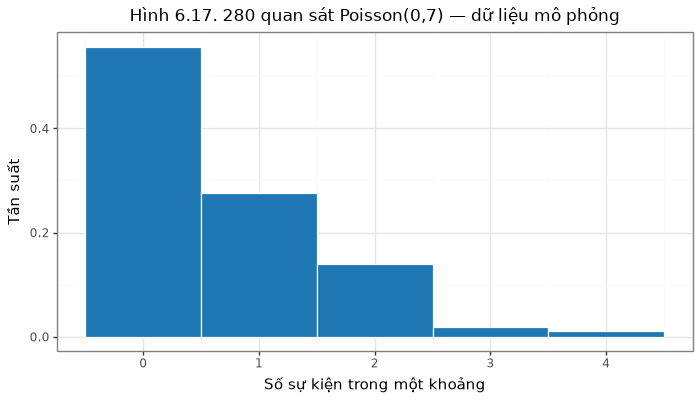

,Số sự kiện,Số khoảng,Tần suất
0,0,156,0.557143
1,1,77,0.275000
2,2,39,0.139286
3,3,5,0.017857
4,4,3,0.010714


In [31]:
su_kien_hiem = rng.poisson(lam=0.7, size=280)
k_hiem = np.arange(su_kien_hiem.max() + 1)
f_hiem = np.array([(su_kien_hiem == k).mean() for k in k_hiem])

bang_su_kien_hiem = pd.DataFrame({'k': k_hiem, 'p': f_hiem})
bieu_do = (p9.ggplot(bang_su_kien_hiem, p9.aes('k', 'p'))
    + p9.geom_col(width=1, fill='#1f77b4', color='white')
    + p9.scale_x_continuous(breaks=k_hiem)
    + p9.labs(x='Số sự kiện trong một khoảng', y='Tần suất',
              title='Hình 6.17. 280 quan sát Poisson(0,7) — dữ liệu mô phỏng'))
bieu_do.show()
display(pd.DataFrame({'Số sự kiện': k_hiem, 'Số khoảng': np.rint(280*f_hiem).astype(int), 'Tần suất': f_hiem}))

Histogram mô phỏng cho thấy dạng điển hình của số sự kiện hiếm. Dạng hình giống nhau không đủ để chứng minh một bộ dữ liệu thật tuân theo Poisson: cần xem cơ chế, tính ổn định của tốc độ và sự phụ thuộc giữa các khoảng.

<a id="hoc-42fbaac1"></a>
## 7. Dịch câu hỏi thành xác suất và chọn mô hình

### Bảng tra lệnh SciPy

Với biến nhận giá trị nguyên, các chữ trong câu hỏi quyết định hàm cần gọi:

| Câu hỏi | Công thức | Lệnh trên một phân phối `rv` |
|---|---|---|
| Đúng $k$ | $P(X=k)$ | `rv.pmf(k)` |
| Không quá $k$ | $P(X\leq k)$ | `rv.cdf(k)` |
| Ít hơn $k$ | $P(X\leq k-1)$ | `rv.cdf(k-1)` |
| Nhiều hơn $k$ | $P(X>k)$ | `rv.sf(k)` |
| Ít nhất $k$ | $P(X>k-1)$ | `rv.sf(k-1)` |
| Từ $a$ đến $b$, gồm hai đầu nguyên | $F_X(b)-F_X(a-1)$ | `rv.cdf(b)-rv.cdf(a-1)` |

`sf` là viết tắt của survival function: $\mathrm{sf}(k)=1-\mathrm{cdf}(k)=P(X>k)$. SciPy tính trực tiếp để tránh mất độ chính xác khi xác suất đuôi rất nhỏ. Bảng chỉ dành cho biến nhận giá trị nguyên. Với giá trị rời rạc không nguyên, xác định đúng điểm ngay trước cận, hoặc cộng trực tiếp các khối.

Ô sau làm bốn phép tính tiêu biểu. Phép siêu bội cuối dùng một hộp **30 linh kiện, 6 lỗi, lấy 5 không hoàn lại**; khác hộp 10 lá của Ví dụ 14.

In [32]:
p_dung_11 = stats.binom.pmf(11, n=12, p=0.95)
p_it_nhat_11 = stats.binom.sf(10, n=12, p=0.95)
p_qua_6 = stats.poisson.sf(6, mu=4)
p_dung_2 = stats.hypergeom.pmf(2, M=30, n=6, N=5)
for ten, p in [('Đúng 11 sản phẩm đạt', p_dung_11),
               ('Ít nhất 11 sản phẩm đạt', p_it_nhat_11),
               ('Hơn 6 yêu cầu', p_qua_6),
               ('Đúng 2 lỗi từ 5 linh kiện', p_dung_2)]:
    print(f'{ten}: {p:.4f}')

Đúng 11 sản phẩm đạt: 0.3413
Ít nhất 11 sản phẩm đạt: 0.8816
Hơn 6 yêu cầu: 0.1107
Đúng 2 lỗi từ 5 linh kiện: 0.2130


Các kết quả lần lượt là 0,3413; 0,8816; 0,1107; 0,2130. Mỗi con số chỉ có nghĩa cùng với biến được đếm và điều kiện của mô hình. Tham số `mu` của Poisson là $\lambda$; ba đối số siêu bội của SciPy phải gắn đúng với kích thước hộp, số thành công và cỡ mẫu.

### Ví dụ 19 — Ghép tình huống với mô hình

Ghép từng tình huống với Bernoulli, nhị thức, siêu bội hoặc Poisson. Nêu điều kiện cần để mô hình hợp lý.

1. Một gói hàng có đến đúng hạn hay không.
2. Số gói đến đúng hạn trong 20 gói độc lập.
3. Số cuộc gọi tới tổng đài trong 10 phút.
4. Số sinh viên thuận tay trái trong 20 sinh viên lấy ngẫu nhiên không hoàn lại từ một khoa có 180 sinh viên.

Tên mô hình phải đi cùng cách thử. Với tình huống 4, biết 180 và 20 đã đủ để tính xác suất cụ thể chưa?

<details><summary>Đáp án và cách lập luận</summary>

1. **Bernoulli.** Mã hóa đúng hạn là 1, trễ hạn là 0; tham số là xác suất đúng hạn.
2. **Nhị thức** với $n=20$, nếu các gói độc lập và cùng xác suất đúng hạn $p$. Độc lập đã được đề cho; điều kiện $p$ không đổi vẫn cần nêu.
3. **Poisson.** Tham số là số cuộc gọi trung bình trong 10 phút, nếu tốc độ ổn định và số cuộc gọi ở các khoảng không giao nhau độc lập.
4. **Siêu bội** với $N=180$, $n=20$, vì mẫu ngẫu nhiên không hoàn lại từ một tổng thể hữu hạn. Cần biết thêm $K$, số sinh viên thuận tay trái trong khoa, mới tính được xác suất cụ thể.

Có thể xác định họ mô hình khi chưa đủ tham số để tính số. Mỗi mô hình chỉ phù hợp khi các điều kiện đi kèm được đáp ứng đủ gần với thực tế.

</details>

### Bảng kiểm tra nhanh khi chọn mô hình

| Câu hỏi | Nếu đúng, nghĩ đến |
|---|---|
| Chỉ một lần thử, hai loại kết quả? | Bernoulli |
| Hữu hạn giá trị, mỗi giá trị khả năng như nhau? | Đều rời rạc |
| Đếm số thành công trong $n$ lần thử độc lập, cùng xác suất $p$? | Nhị thức |
| Đếm số phần tử "đặc biệt" khi rút $n$ phần tử **không hoàn lại** từ một tổng thể nhỏ? | Siêu bội |
| Đếm số lần sự kiện xảy ra trong một khoảng, không có cận trên rõ ràng, sự kiện hiếm và độc lập? | Poisson |

<a id="hoc-ffef637c"></a>
## 8. Hai bài toán tổng hợp

### Ví dụ 20 — Cảnh báo giả của cảm biến

Hệ thống có 8 cảm biến hoạt động độc lập. Trong một ca, mỗi cảm biến phát cảnh báo giả với xác suất 0,04.

1. Lập phân phối của số cảnh báo giả $X$.
2. Tính xác suất có ít nhất một cảnh báo giả.

**Bạn đoán trước:** xác suất toàn hệ thống có cảnh báo giả có bằng 0,04 không? Số 0,04 mô tả một cảm biến, còn hệ thống có tám cơ hội phát cảnh báo.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* 8 cảm biến cố định, mỗi cảm biến báo giả hoặc không, độc lập, cùng xác suất 0,04. Vậy $X\sim\operatorname{Binomial}(8;\ 0{,}04)$:
$$P(X=k)=\binom8k(0{,}04)^k(0{,}96)^{8-k},\qquad k=0,\ldots,8.$$

*Câu 2.* "Ít nhất một" là phần bù của "không cảm biến nào báo":
$$P(X\ge1)=1-P(X=0)=1-(0{,}96)^8\approx0{,}2786\approx0{,}279.$$

Theo mô hình độc lập, hệ thống có ít nhất một cảnh báo giả trong ca với xác suất khoảng 27,86%, lớn hơn nhiều so với 0,04 của một cảm biến. Không cộng $8\cdot0{,}04=0{,}32$: các biến cố cảnh báo của các cảm biến không xung khắc (nhiều cảm biến có thể cùng báo), nên tổng đó chỉ là chặn trên (Tuần 05).

</details>

In [33]:
k_cam_bien = np.arange(9)
p_cam_bien = stats.binom.pmf(k_cam_bien, n=8, p=0.04)
display(pd.DataFrame({'Số cảnh báo giả': k_cam_bien, 'PMF': p_cam_bien}))
print('P(ít nhất 1) = 1-0.96^8 =', round(1-0.96**8, 4))
print('Kiểm tra sf(0):', round(stats.binom.sf(0, n=8, p=0.04), 4))
assert np.isclose(1-0.96**8, stats.binom.sf(0, n=8, p=0.04))

,Số cảnh báo giả,PMF
0,0,7.213896e-01
1,1,2.404632e-01
2,2,3.506755e-02
3,3,2.922296e-03
4,4,1.522029e-04
5,5,5.073430e-06
6,6,1.056965e-07
7,7,1.258291e-09
8,8,6.553600e-12


P(ít nhất 1) = 1-0.96^8 = 0.2786
Kiểm tra sf(0): 0.2786


Nếu một nguồn nhiễu chung làm nhiều cảm biến cùng báo, điều kiện độc lập có thể sai. Khi đó không nên giữ phép tính $0{,}96^8$ chỉ vì mỗi cảm biến vẫn có xác suất báo 0,04. Điều kiện của mô hình quyết định cách kết hợp các xác suất.

### Ví dụ 21 — Tồn kho hai loại bộ mở cửa garage

Cửa hàng bán loại truyền động xích và loại truyền động trục. Mỗi khách mua một bộ, các lựa chọn độc lập. Xác suất chọn xích là 0,75 và chọn trục là 0,25. Tồn kho gồm 10 bộ xích và 8 bộ trục. Xét 15 khách tiếp theo, không nhập thêm hàng, và khách không đổi sang loại khác khi hết hàng.

1. Lập phân phối của $X$, số khách chọn loại xích.
2. Tính xác suất đáp ứng được cả 15 khách bằng lượng hàng hiện có.

*Gợi ý.* Có 18 bộ cho 15 khách, nhưng chưa biết có đủ **đúng loại** không. Viết riêng hai điều kiện tồn kho, rồi tìm phần giao của chúng.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* 15 khách, mỗi khách chọn xích với xác suất 0,75, độc lập. Vậy $X\sim\operatorname{Binomial}(15;\ 0{,}75)$:
$$P(X=k)=\binom{15}k(0{,}75)^k(0{,}25)^{15-k},\quad k=0,\ldots,15.$$

*Câu 2.* Phục vụ đủ 15 khách cần **đồng thời** hai điều kiện:

- đủ xích: $X\le10$;
- đủ trục: số khách chọn trục là $15-X\le8$, tức $X\ge7$.

Giao của hai điều kiện là $A=\{7\le X\le10\}$:
$$P(A)=\sum_{k=7}^{10}\binom{15}k(0{,}75)^k(0{,}25)^{15-k}=F_X(10)-F_X(6)\approx0{,}3093.$$

Xác suất phục vụ đủ khoảng 30,93%. Tổng hàng (18 bộ) lớn hơn tổng khách (15) chưa bảo đảm đủ đúng loại. Tồn kho giảm dần không làm **lựa chọn của khách** trở thành siêu bội: đề giả sử khách không đổi loại khi hết hàng, và ta đang đếm nhu cầu chứ không rút ngẫu nhiên từ kho.

</details>

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='k', y='p', fill='Tinh_trang'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

Miền đủ hàng: [ 7  8  9 10]
Tính bằng tổng PMF: 0.3093
Tính bằng F(10)-F(6): 0.3093


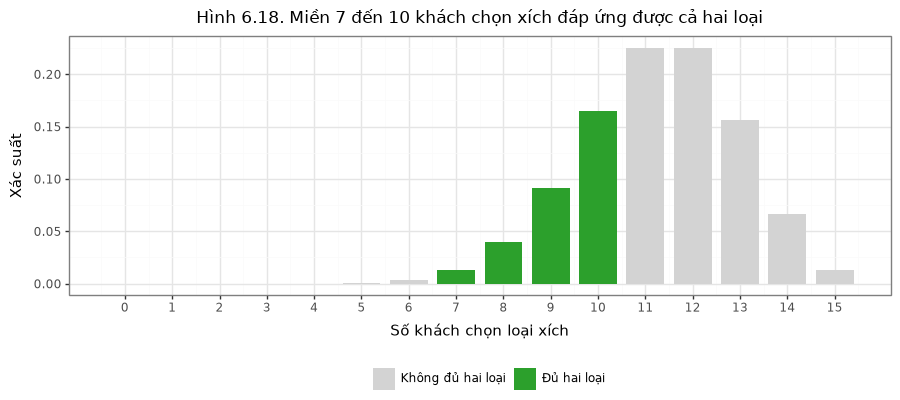

In [34]:
k_kho = np.arange(16)
p_kho = stats.binom.pmf(k_kho, n=15, p=0.75)
du_hang = (k_kho <= 10) & (15-k_kho <= 8)
p_du_hang_tay = p_kho[du_hang].sum()
p_du_hang_cdf = stats.binom.cdf(10, n=15, p=0.75) - stats.binom.cdf(6, n=15, p=0.75)
print('Miền đủ hàng:', k_kho[du_hang])
print('Tính bằng tổng PMF:', round(p_du_hang_tay, 4))
print('Tính bằng F(10)-F(6):', round(p_du_hang_cdf, 4))
assert np.isclose(p_du_hang_tay, p_du_hang_cdf)

bang_kho = pd.DataFrame({'k': k_kho, 'p': p_kho,
                         'Tinh_trang': np.where(du_hang, 'Đủ hai loại', 'Không đủ hai loại')})
bieu_do = (p9.ggplot(bang_kho, p9.aes('k', 'p', fill='Tinh_trang'))
    + p9.geom_col(width=0.8)
    + p9.scale_fill_manual(values={'Đủ hai loại': '#2ca02c', 'Không đủ hai loại': 'lightgray'})
    + p9.scale_x_continuous(breaks=k_kho)
    + p9.labs(x='Số khách chọn loại xích', y='Xác suất', fill='',
              title='Hình 6.18. Miền 7 đến 10 khách chọn xích đáp ứng được cả hai loại')
    + p9.theme(figure_size=(9, 4)))
bieu_do.show()

Các cột xanh cộng lại thành xác suất đáp ứng đủ. *Thử thay đổi:* đổi tồn kho xích và trục trong biểu thức `du_hang`, dự đoán miền đủ hàng trước khi chạy lại. Tăng số hàng một loại có thể mở rộng miền nhu cầu được chấp nhận; phân phối **nhu cầu của khách** thì giữ nguyên khi các giả định về lựa chọn không đổi.

<a id="hoc-r6-005"></a>
## 9. Tóm tắt và lỗi hay gặp

| Đối tượng | Công thức | Đọc thành lời |
|---|---|---|
| PMF | $p_X(x)=P(X=x)$, $\sum_x p_X(x)=1$ | Xác suất tại từng giá trị; mọi khối cộng lại bằng 1. |
| CDF | $F_X(t)=P(X\le t)$ | Xác suất không vượt ngưỡng $t$, kể cả bằng $t$. |
| Khoảng | $P(a<X\le b)=F_X(b)-F_X(a)$ | Đầu trái bị loại, đầu phải được lấy. |
| Chỉnh hợp | $A_n^k=\dfrac{n!}{(n-k)!}$ | Chọn $k$ trong $n$, có thứ tự. |
| Tổ hợp | $\binom nk=\dfrac{n!}{k!\,(n-k)!}$ | Chọn $k$ trong $n$, không tính thứ tự. |
| Đều rời rạc | $P(X=k)=\dfrac1m$ | $m$ giá trị, cùng khả năng. |
| Bernoulli$(p)$ | $P(X=1)=p$, $P(X=0)=1-p$ | Một lần thử, mã hóa 0/1. |
| Binomial$(n,p)$ | $\binom nk p^k(1-p)^{n-k}$ | Số chuỗi có $k$ thành công nhân xác suất một chuỗi. |
| Hypergeometric$(N,K,n)$ | $\dfrac{\binom Kk\binom{N-K}{n-k}}{\binom Nn}$ | Số nhóm thuận lợi chia cho số nhóm $n$ lá. |
| Poisson$(\lambda)$ | $\dfrac{e^{-\lambda}\lambda^k}{k!}$ | Số sự kiện trong một khoảng, trung bình $\lambda$. |
| Cộng Poisson | $\operatorname{Poisson}(\lambda)+\operatorname{Poisson}(\mu)=\operatorname{Poisson}(\lambda+\mu)$ | Khi hai biến độc lập. |

Một phân phối xác suất mô tả mô hình **trước** khi quan sát; một biểu đồ tần suất mô tả dữ liệu đã có. Mô phỏng làm hiện rõ dao động mẫu và giúp kiểm tra phép tính, nhưng không chứng minh mô hình đúng với thực tế.

### Lỗi hay gặp

| Lỗi | Sửa |
|---|---|
| Chia đều xác suất cho các giá trị của $X$ (ví dụ 11 tổng của hai xúc xắc) | Đếm ở cấp kết quả đồng khả năng, rồi gom theo giá trị. |
| Nhầm "ít hơn $k$" với "không quá $k$" | Với $X$ nguyên: $P(X<k)=F(k-1)$, $P(X\le k)=F(k)$. |
| Gọi `sf(k)` cho "ít nhất $k$" | `sf(k)` là $P(X>k)$; "ít nhất $k$" là `sf(k-1)`. |
| Dùng nhị thức cho rút không hoàn lại từ hộp nhỏ | Dùng siêu bội; nhị thức chỉ là xấp xỉ khi hộp rất lớn so với mẫu. |
| Dùng $\lambda$ của một giây cho khoảng ba giây | $\lambda=$ tốc độ $\times$ độ dài khoảng. |
| Cộng xác suất của các biến cố không xung khắc ($8\cdot0{,}04$) | Dùng phần bù: $1-(0{,}96)^8$. |
| Tử số đếm có thứ tự, mẫu số không thứ tự | Đếm tử và mẫu theo cùng một cách. |

<a id="hoc-7d4cb0d0"></a>
## 10. Tự kiểm tra trước Tuần 07

Trước mỗi bài, hãy tự hỏi:

1. Biến ngẫu nhiên đang đếm hay đo cái gì? Nó nhận những giá trị nào?
2. Cơ chế sinh dữ liệu là gì: số lần thử cố định hay không, có hoàn lại hay không, các lần thử có độc lập không?
3. Câu hỏi dùng dấu $=$, $<$, $\le$, $>$ hay $\ge$? Đổi sang PMF hoặc CDF thế nào?
4. Bảng phân phối đã cộng lại bằng 1 chưa?

**Câu hỏi.**

1. Một mật khẩu gồm 4 chữ số (0–9), cho phép lặp lại. Có bao nhiêu mật khẩu? Bao nhiêu mật khẩu có 4 chữ số khác nhau?
2. Lớp có 20 nam và 15 nữ. Chọn ngẫu nhiên 3 người. Tính xác suất có đúng 2 nữ.
3. Một dây chuyền có 2% sản phẩm lỗi. Lấy độc lập 50 sản phẩm. Viết xác suất có đúng 1 sản phẩm lỗi theo mô hình nhị thức, và theo xấp xỉ Poisson.
4. Một lô có 20 sản phẩm, trong đó 3 sản phẩm lỗi. Lấy 5 sản phẩm không hoàn lại. Tính xác suất không có sản phẩm lỗi nào.
5. Vì sao không dùng được nhị thức cho "số lần gieo xúc xắc cho đến khi ra mặt 1"?

<details><summary>Đáp án tự kiểm tra</summary>

1. $10^4=10\,000$ mật khẩu. Có $10\cdot9\cdot8\cdot7=5040$ mật khẩu gồm 4 chữ số khác nhau (chỉnh hợp $A_{10}^4$).
2. $\dfrac{\binom{15}{2}\binom{20}{1}}{\binom{35}{3}}=\dfrac{105\cdot20}{6545}\approx0{,}321$ (siêu bội với $N=35$, $K=15$, $n=3$).
3. Nhị thức: $\binom{50}{1}(0{,}02)(0{,}98)^{49}\approx0{,}372$. Poisson với $\lambda=50\cdot0{,}02=1$: $e^{-1}\approx0{,}368$.
4. $\dfrac{\binom30\binom{17}5}{\binom{20}5}=\dfrac{6188}{15\,504}\approx0{,}399$.
5. Số lần thử không cố định trước, nên vi phạm điều kiện thứ nhất của mô hình nhị thức.

</details>

Ở Tuần 07, ta dùng cùng bảng PMF để hỏi hai câu tiếp theo: **trung bình dài hạn của $X$ là bao nhiêu, và các kết quả dao động quanh đó thế nào?** Trước buổi sau, hãy ôn cách lập PMF, cách tính xác suất bằng CDF và cách kiểm tra điều kiện mô hình.

<a id="hoc-r6-006"></a>
## 11. Đọc thêm trong STAT 20 bản dịch

- **§3.4 Phân phối xác suất:** hộp lá thăm, quy tắc đếm, các phân phối đặc biệt.
- **§4.1–4.4 Biến ngẫu nhiên:** ví dụ, đặt cược vào đỏ trong roulette, phân phối rời rạc đặc biệt, nhị thức so với siêu bội, hàm phân phối tích lũy.

Mục §3.4.4 và §4.5 hướng dẫn ngôn ngữ R; học phần dùng Python nên có thể bỏ qua phần code R.

### Nguồn học liệu

Đề cương UET.MAT1052, Buổi 6, §3.4–3.5; bài giảng Tuần 6; STAT 20 bản dịch tiếng Việt, §3.4 và §4.1–4.6. Các ví dụ về quy tắc đếm, roulette và xấp xỉ phân phối sử dụng những mục tương ứng trong bản dịch.
